<a href="https://colab.research.google.com/github/LucasBarbosaSilva/MVPSprint2AnalisePreProcessamento/blob/main/MVP_Sprint_2_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Barbosa Leite Silva

**Matrícula:** 4052025002093

**Dataset:** [Marketing bancário](https://archive.ics.uci.edu/dataset/222/bank+marketing)

# Descrição do Problema

Os dados referem-se a campanhas de marketing direto (chamadas telefônicas) de uma instituição bancária portuguesa. O objetivo da classificação é prever se o cliente irá se inscrever em um depósito a prazo (variável result).

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?
2. Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?
3. Ligar mais vezes para um cliente diminui a chance dele contratar?
4. Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características, (como idade, número de ligações, dias entre as ligações, ocupação e nível de escolaridade), o objetivo é prever qual o resultado final do contato (yes/no).

## Seleção de Dados

O dataset Bank Marketing é um dataset disponível no UCI Machine Learning Repository. Os dados referem-se a campanhas de marketing direto de uma instituição bancária portuguesa. As campanhas de marketing baseavam-se em chamadas telefónicas. Frequentemente, era necessário mais do que um contacto com o mesmo cliente para apurar se o produto (depósito a prazo bancário) seria contratado ("sim") ou não ("não"). O dataset é composto por 45211 instâncias e 17 colunas.

## Atributos do Dataset

O dataset Bank Marketing contém 45211 amostras, cada uma com 17 atributos (16 features e 1 target):

| Variável | Descrição | Tipo | Categorias |
|---       | ---       | ---  | ---        |
| **age**  | idade     | numérica | N/A    |
| **job**  | ocupação  | categórica | admin., blue-collar, entrepneur housemaid, management, retired, self-employed, services, student, <br>technician, unemployed, unknown |
| **marital** | situação conjugal | categórica | maried, single, divorced* unknown|
| **education** | nível de educação	| categórica | primary, secondary, tertiary, unknown |
| **default** | já entrou em incumprimento financeiro no passado?  | binária | yes/no |
| **balance** | saldo médio anual, em euros | numérica | N/A |
| **housing** | possui empréstimo imobiário?  | binária | yes/no |
| **loan** | possui empréstimo pessoal?  | binária | yes/no |
| **contact** | tipo de contato | categórica | cellular, telephone |
| **day** | último dia de contato  | numérica | N/A |
| **month** | mês do último contato | categórica | jan, feb, mar, ... oct, nov, dec |
| **duration** | duração do último contato, em segundos** |  numérico | N/A |  
| **campaign** | número de contatos realizados durante esta campanha para este cliente (inclui o último contato) | numérico | N/A |
| **pdays** | dias de folga: Número de dias decorridos desde o último contato com o  cliente em uma <br> campanha anterior.*** | numérico | N/A |
| **previous** | número de contatos realizados antes desta campanha para  este cliente. | numérica | N/A |
| **poutcome** | resultado da campanha de marketing anterior | categórica  | sucess, failuer, other |
| **result** | O cliente subscreveu um depósito prazo  | binária | yes/no |

\* Nota 1: divorcidado refere-se tanto a pessoas divorciadas, quanto a pessoas viúvas.

** Nota 2: o atributo duração afeta significativamente o resultado esperado (por exemplo, se a duração for igual a 0, então y = 'não').

*** Nota 3: -1 significa que o cliente não foi contatado anteriormente.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Bank Marketing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from matplotlib import colors

Baixando o arquivo 'bank-full.csv' disponibilizado no GitHub e criando dataframe pandas:

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/LucasBarbosaSilva/MVPSprint2AnalisePreProcessamento/main/dataset/bank-full.csv', sep=';')
df = df.rename(columns={'y': 'result'})

In [3]:
# primeiras linhas
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,result
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Bank Marketing, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

A seguir apresentamos uma análise inicial dos dados do dataset:

In [4]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 45211

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  result     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


Como podemos ver, algumas das colunas possuem valores nulos. Com algumas análises, poderemos verificar qual a melhor abordagem para tratar esses valores.

## Distribuição das categorias

In [5]:
df.groupby('result', dropna=False).size()

,0
result,
no,39922
yes,5289


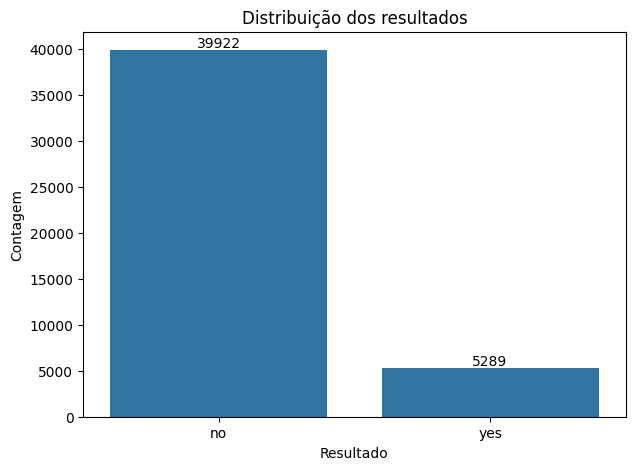

In [6]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
df['result'] = df['result'].fillna('NaN')
axes = sns.countplot(x='result', data=df)
plt.title('Distribuição dos resultados')
plt.xlabel('Resultado')
plt.ylabel('Contagem')
plt.bar_label(axes.containers[0])
plt.show()

O gráfico de barras mostra um desbalanceamento entre as categorias. Enquanto cerca de 5 mil (12%) são registros de casos bem-sucedidos, 40 mil (88%) são registros de casos mal-sucedidos. Na etapa de pré-processamento iremos verificar a melhor forma de diminuir essa diferença.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [7]:
# estatísticas descritivas básicas do dataset
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Análise inicial:**
- **age**: os valores de idade parecem estar dentro de uma distribuição esperada, com valores mínimos e máximos dentro do esperado.
- **balance**: o balanço médio anual apresenta uma amplitude de valores (min: -8019 e max: 102127). Embora, sejam valores significativos, não necessariamente são outliers, indicando que o banco buscou abordar diferentes tipos de clientes.
- **day**: os valores demonstram que são dias do mês e que estão dentro do limite aceitável, entre 1 e 31.
- **duration**: embora represente o tempo em segundos, o valor máximo ser de 4918 (81 minutos) provavelmente indica um outiler.
- **campaign**: não temos a informação de quanto tempo durou a campanha, mas pelas informações descritivas (média, desvio padrão e mediana), o valor máximo de 63 ligações pode representar um outlier.
- **pdays**: dias de folga, desde o último contato. O valor -1 indica que não que o cliente não foi contatado anteriormente. Um ponto de atenção é que pelo menos 75% do conjunto de dados é composto de -1, indicando que a grande maioria dos contatos foram feitos pela primeira vez. Além disso, o valor máximo de 871 é um provável outlier, pois é valor muito discrepante dos demais valores da distribuição.
- **previous**: número de contatos realizados antes dessa campanha. As informações apresentadas demonstram que pelo menos 75% do conjunto de clientes nunca foi contatado em campanhas anteriores. Desse modo, o valor máximo de 275 também pode representar um outlier.

## *Análise das variáveis*
Além das medidas descritivas, é importante analisar a **distribuição dos dados**. Esta análise é crucial, pois permite um melhor entendimento dos dados, revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers).

Dentre os principais gráficos para realizar esta análise destacam-se o **histograma**, **gráfico de barras** e o **boxplot**. O *histograma* é utilizado para avaliar variáveis contínuas, representando a distribuição dos dados, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

O *gráfico de barras*, por sua vez, permite contar a quantidade de observações por variável categórica e realizar análises como comparação, contagem, rankeamento.

Já o *boxplot* é amplamente utilizado quando queremos comparar diferentes distribuições. Ele permite analisar quartis, medianas e outliers por variável.

A seguir traremos a análise de cada uma das variáveis do dataset.

In [8]:
def plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, x_label, target):
  fig, ax = plt.subplots(1,2, figsize = figsize)
  fig.suptitle(f'Análise da variável {variable}')

  sns.histplot(data=df, kde=True, binwidth=binwidth, x=variable, hue=target, palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
  ax[0].set_xlabel(x_label)
  ax[0].set_ylabel('Frequência')

  sns.boxplot(x=target, y=variable, data=df, hue=target, palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
  ax[1].set_xlabel('Resultado')
  ax[1].set_ylabel(x_label)
  plt.show()

In [9]:
def plot_barh_by_hue_result(figsize, df, variable, label, target):
  fig, ax = plt.subplots(2,1, figsize = figsize)
  fig.suptitle(f'Análise da variável {variable}')

  # plot 1
  # Preparação do df
  df_group = df.groupby([variable, target], as_index=False, dropna=False).size()
  df_group['total'] = df_group.groupby(variable, dropna=False)['size'].transform('sum')
  df_pivot = df_group.pivot(index=variable, columns=target, values='size')

  df_pivot['total'] = df_pivot[['yes', 'no']].sum(axis=1)
  df_pivot = df_pivot.sort_values(by="total", ascending=True)
  df_pivot.drop(columns=['total'], inplace=True)

  # plot
  df_pivot.plot(kind='barh', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
  ax[0].set_xlabel('Quantidade')
  ax[0].set_ylabel(label)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[0].text(no/2, i, f"{no}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(no + yes/2, i, f"{yes}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(no+yes+100, i, f"Total: {no+yes}", va='center', ha='left', fontsize=9, color='blue')

  # plot 2
  # Preparação do df
  df_group['percent'] = df_group.groupby(variable, dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
  df_pivot = df_group.pivot(index=variable, columns=target, values='percent')
  df_pivot = df_pivot.sort_values(by="yes", ascending=True)

  # plot
  df_pivot.plot(kind='barh', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
  ax[1].set_xlabel('Percentual')
  ax[1].set_ylabel(label)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[1].text(no/2, i, f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
      ax[1].text(no + yes/2, i, f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
  plt.tight_layout()
  plt.show()

In [10]:
def plot_bar_by_hue_result(figsize, df, variable, label, target):
  fig, ax = plt.subplots(1,2, figsize = figsize)
  fig.suptitle(f'Análise da variável {variable}')

  # plot 1
  # Preparação do df
  df_group = df.groupby([variable, target], as_index=False, dropna=False).size()
  df_group['total'] = df_group.groupby(variable, dropna=False)['size'].transform('sum')
  df_pivot = df_group.pivot(index=variable, columns=target, values='size')
  df_pivot['total'] = df_pivot[['yes', 'no']].sum(axis=1)
  df_pivot = df_pivot.sort_values(by="total", ascending=False)
  df_pivot.drop(columns=['total'], inplace=True)

  # plot
  df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
  ax[0].set_xlabel(label)
  ax[0].set_ylabel('Quantidade')
  ax[0].tick_params(axis='x', labelrotation=0)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

  # plot 2
  # Preparação do df
  df_group['percent'] = df_group.groupby(variable, dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
  df_pivot = df_group.pivot(index=variable, columns=target, values='percent')
  df_pivot = df_pivot.sort_values(by="yes", ascending=False)

  # plot
  df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
  ax[1].set_xlabel(label)
  ax[1].set_ylabel('Percentual')
  ax[1].tick_params(axis='x', labelrotation=0)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
      ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
  plt.tight_layout()
  plt.show()
  return df_group

### age (idade)

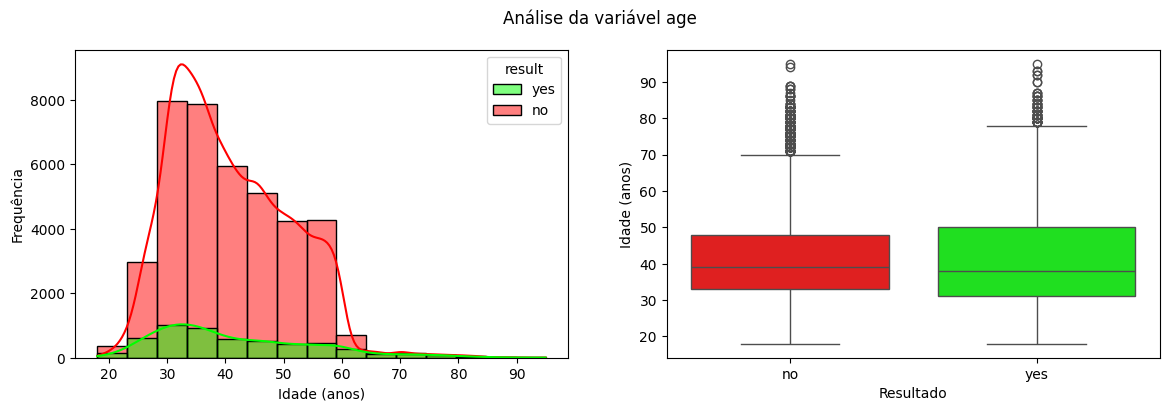

In [11]:
figsize = (14, 4)
variable = 'age'
binwidth = 5
x_label = 'Idade (anos)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, x_label, target)

**Gráfico da esquerda:** histograma dos valores da variável age, com largura dos bins fixada em 5 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável age, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [12]:
print("Valores nulos:", df['age'].isnull().sum())

Valores nulos: 0


Como observado no gráfico de histograma, a distribuição da variável age quase se aproxima de uma distribuição normal, no entanto há uma concentração maior de dados a esquerda do que a direita.

A grande diferença entre casos negativos e casos positivos, acaba dificultando uma análise clara das curvas de comportamento. Após a etapa de pré-processamento, espera-se poder observar melhor a influência dessa variável com relação ao resultado da campanha.

No entanto, a priori, podemos dizer que não há uma distinção tão evidente no formato da curva dos que negaram o contrato, para os que aceitaram o contrato.

Embora o gráfico de boxplot evidencie outliers, observa-se que os valores apresentados estão dentro dos limites consideráveis de tempo de vida humana, ou seja, seriam outliers naturais. Por fim, observa-se que não há valores nulos.

### job (ocupação)

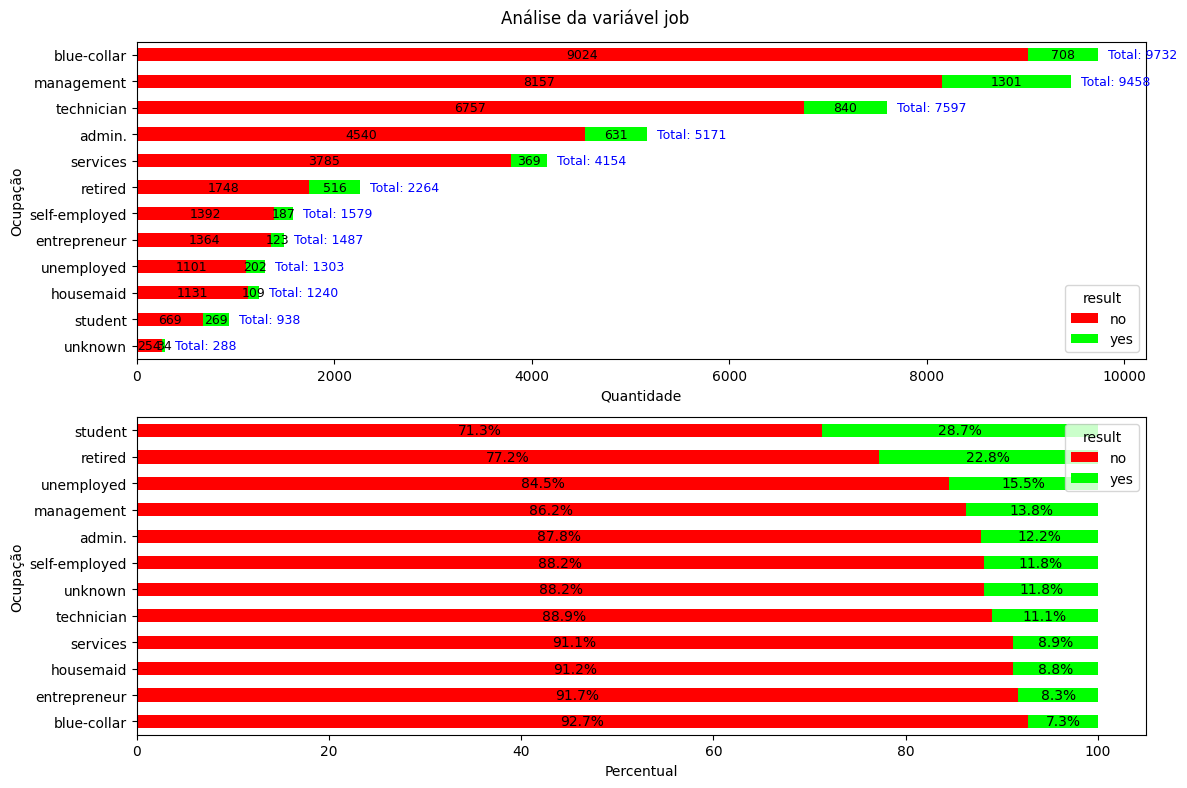

In [13]:
figsize = (12, 8)
variable = 'job'
label = 'Ocupação'
target = 'result'
plot_barh_by_hue_result(figsize, df, variable, label, target)

**Gráfico superior:** gráfico de barras horizontais da quantidade de registros por ocupação, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por ocupação.

**Gráfico inferior:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por ocupação. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [14]:
print("Valores nulos:", df['job'].isnull().sum())

Valores nulos: 0


Novamente, o desbalanceamento do dataset acaba dificultando a análise pura da quantidade de ocorrências por ocupação. Por esse motivo, um segundo gráfico foi apresentado, para analisar o percentual de aceite da campanha por ocupação. O primeiro gráfico está ordenado pelo total de registros por ocupação. Já o segundo, está ordenado por maior percentual de aceitação da campanha.

Com isso, observamos que a ocupação 'blue-collar' foi a mais contatada, seguida pelo 'management' e 'technician'. Mas as ocupações com maior taxa de aceitação foi 'student' (quase 30% de aceitação), 'retired' (22%) e 'unemployed' (15%). Blue-collar, a ocupação mais contatada, foi a de menor taxa de aceitação (7%).

Por fim, observa-se que não há registros nulos.

### marital (estado civil)

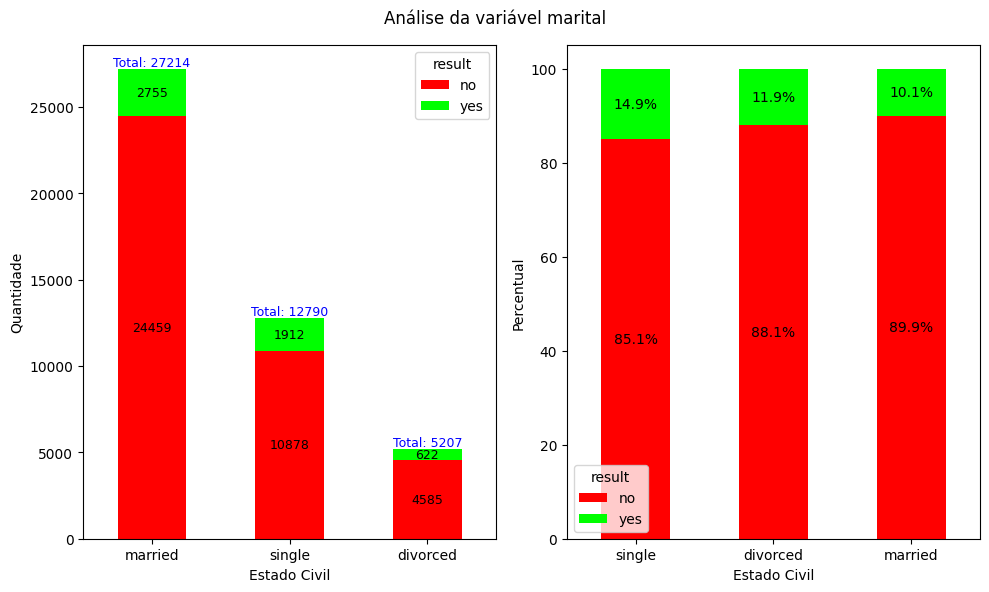

In [15]:
figsize = (10, 6)
variable = 'marital'
label = 'Estado Civil'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por estado civil, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por estado civil.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por estado civil. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [16]:
print("Valores nulos:", df['marital'].isnull().sum())

Valores nulos: 0


Embora haja uma diferença significativa de quantidade de registros de cada estado civil, a diferença entre os valores percentuais não é tão discrepante, indicando que essa variável, possivelmente, não influencia tanto no resultado da campanha. Por fim, observa-se que não há registros nulos.

### education (nível de escolaridade)

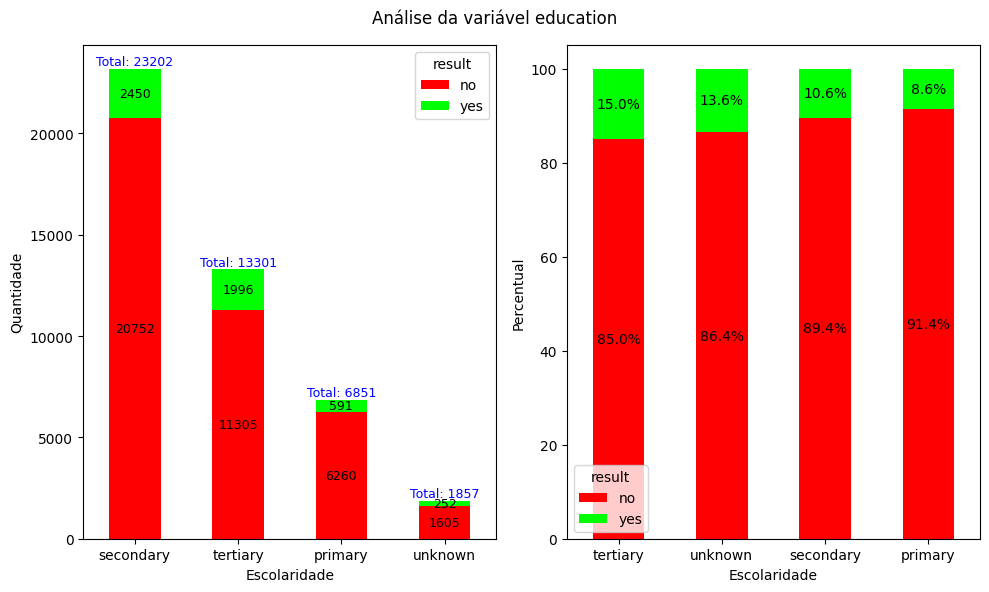

In [17]:
figsize = (10, 6)
variable = 'education'
label = 'Escolaridade'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por nível de escolaridade, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por nível de escolaridade.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por nível de escolaridade. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [18]:
print("Valores nulos:", df['education'].isnull().sum())

Valores nulos: 0


Embora o nível 'secondary' tenha sido o mais contatado, o 'tertiary' foi de maior taxa de aceitação. No entanto, a diferença percentual entre as categorias ainda não seja tão significativa. Por fim, observa-se que não há registros nulos.

### default (incumprimento financeiro no passado?)

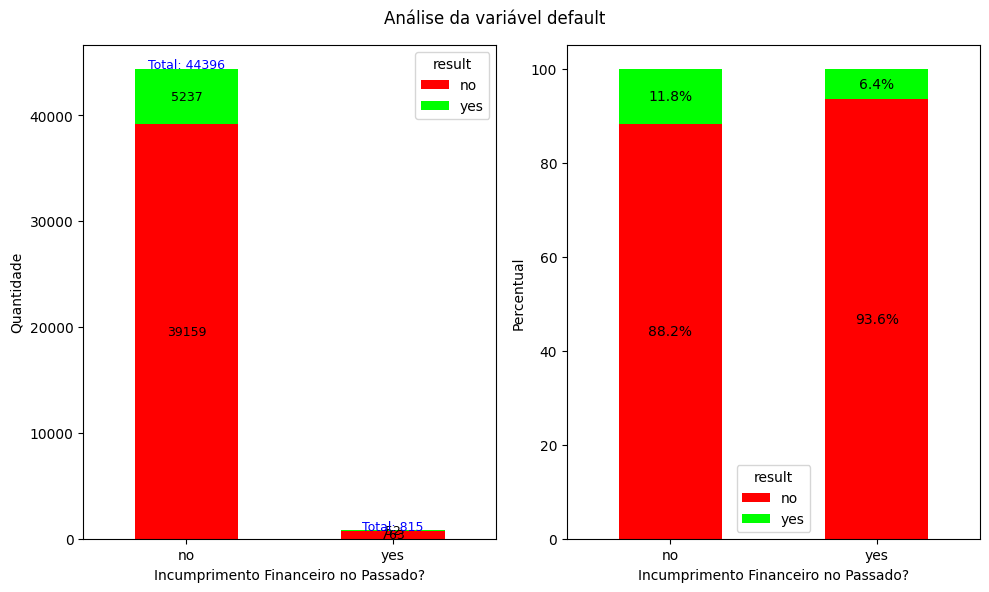

In [19]:
figsize = (10, 6)
variable = 'default'
label = 'Incumprimento Financeiro no Passado?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por situação de incumpimento financeiro, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por situação de incumpimento financeiro.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por situação de incumpimento financeiro. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [20]:
print("Valores nulos:", df['default'].isnull().sum())

Valores nulos: 0


Melhor detalhamento dos valores:

In [21]:
df_group

,default,result,size,total,percent
0,no,no,39159,44396,88.203892
1,no,yes,5237,44396,11.796108
2,yes,no,763,815,93.619632
3,yes,yes,52,815,6.380368


Observamos uma diferença imensa entre a quantidade de pessoas em incumprimento finaceiro (44396) e as que não estão (815). Dessa forma fica difícil avaliar a relevância dessa variável. Em termos percentuais, não há uma diferença significativa. Por fim, observa-se que não há registros nulos.

### balance (saldo médio anual)

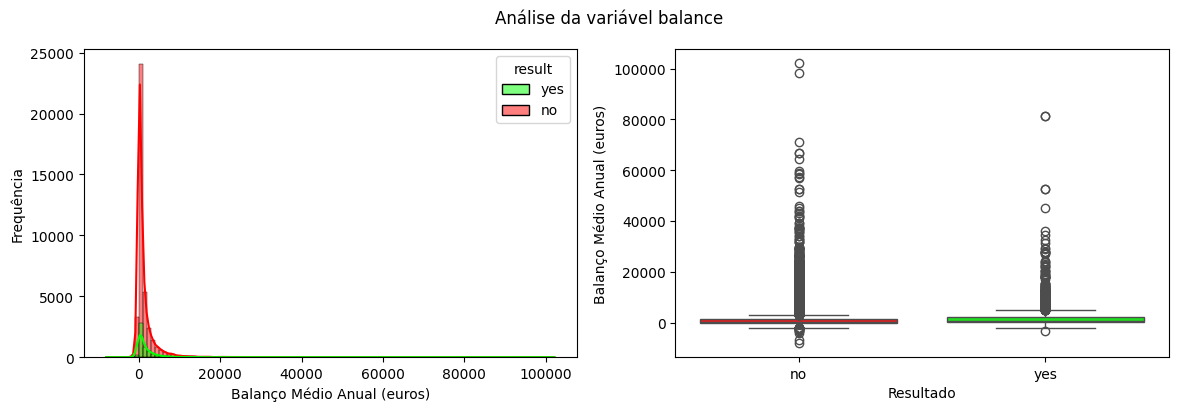

In [22]:
figsize = (14, 4)
variable = 'balance'
binwidth = 1000
label = 'Balanço Médio Anual (euros)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável balance, com largura dos bins fixada em 1000 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável balance, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [23]:
print("Valores nulos:", df['balance'].isnull().sum())

Valores nulos: 0


A variável foi divida em faixa de valores para facilitar a visualização. Vários intervalos foram testados, até chegar no número de 100 bins. A distribuição pode ser considerada assimétrica à direita. Observa-se a presença de outliers, pois uma quantidade ínfima de clientes passa do balanço médio de 20 mil ao ano. Isso pode representar um outlier natural, pois pode haver rendas discrepantes, no entanto precisará ser tratado na etapa de pré-processamento.

A presença desses outliers e o desbalanceamento prejudicaram uma melhor visualização da distribuição. Mas, a priori, o gráfico boxplot não indica uma diferença significativa entre as pessoas que aderiram a campanha. Por fim, observa-se que não há presença de valores nulos.

### housing (possui empréstimo imobiário?)

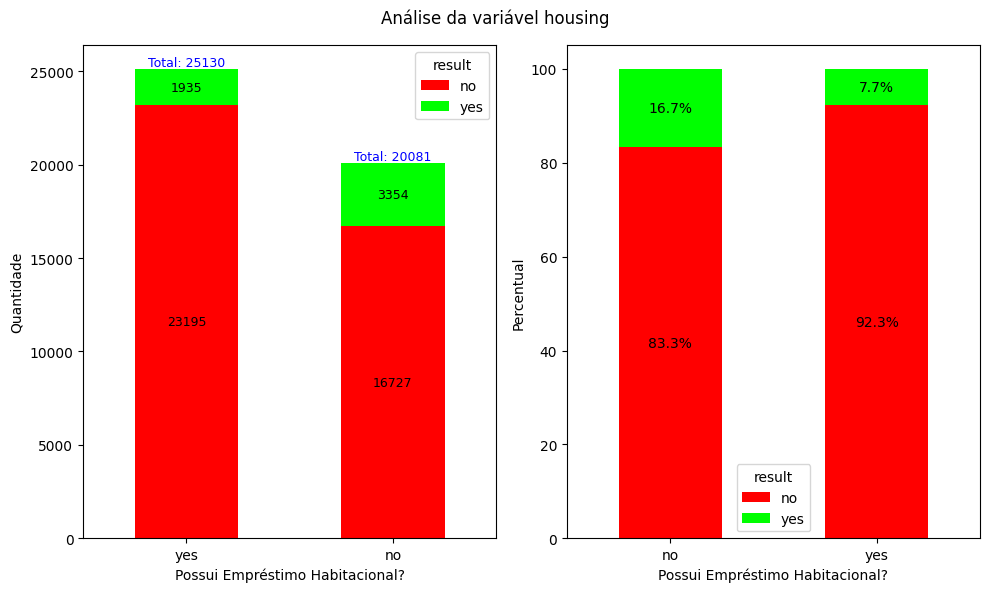

In [24]:
figsize = (10, 6)
variable = 'housing'
label = 'Possui Empréstimo Habitacional?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por situação de empréstimo habitacional, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por situação de empréstimo habitacional.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por situação de empréstimo habitacional. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [25]:
print("Valores nulos:", df['housing'].isnull().sum())

Valores nulos: 0


Esta variável possui um desbalanceamento menos expressivo. Foram contactados cerca de 25 mil clientes que possuiam empréstimo imobiliário, e cerca de 20 mil que não possuiam. Embora a diferença percentual entre as categorias não seja tão significativa, a taxa de adesão à campanha foi maior entre os que não possuiam empréstimo imobiliário. Por fim, observa-se que não há presença de valores nulos.

### loan (possui empréstimo pessoal?)

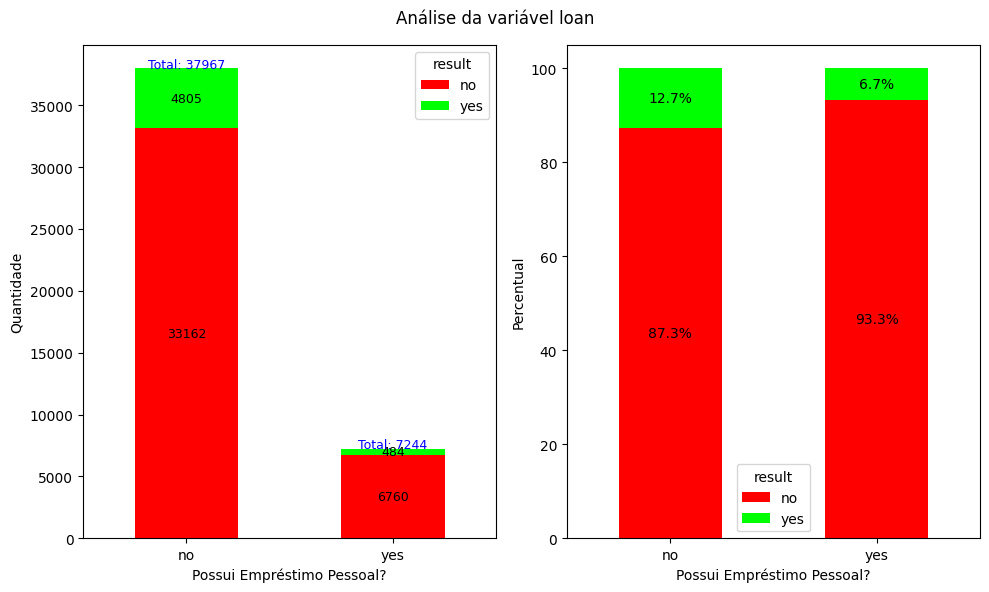

In [26]:
figsize = (10, 6)
variable = 'loan'
label = 'Possui Empréstimo Pessoal?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por situação de empréstimo pessoal, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por situação de empréstimo pessoal.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por situação de empréstimo pessoal. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [27]:
print("Valores nulos:", df['loan'].isnull().sum())

Valores nulos: 0


Há uma quantidade significativa maior de clientes sem empréstimo pessoal, do que os com  empréstimo pessoal. Esse desbalanceamento prejudica a análise. Percentualmente, observa-se uma adesão maior entre os que não possuem empréstimo, do que os que possuem. Por fim, não há presença de valores nulos.

### contact (tipo de contato)

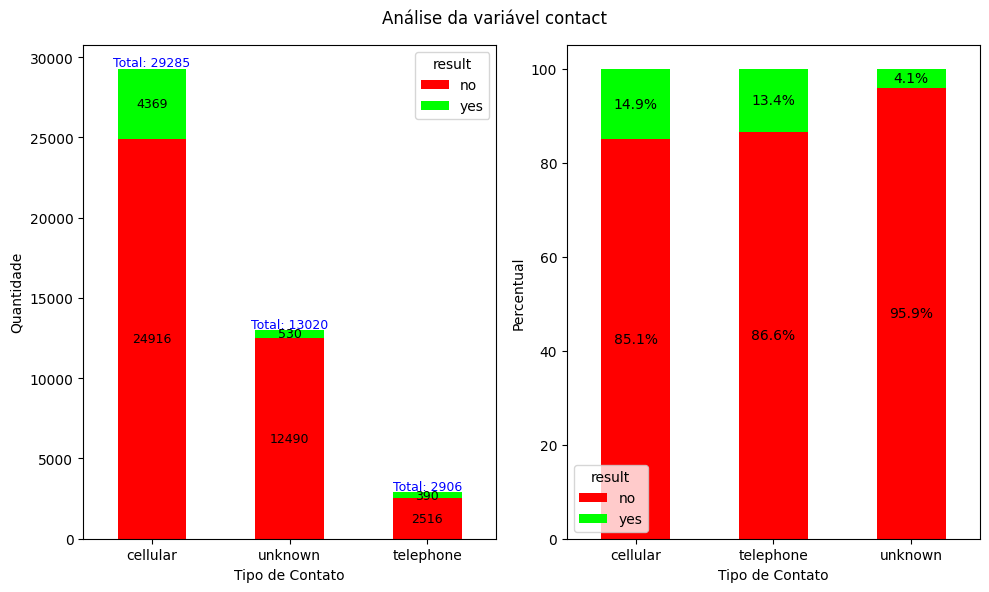

In [28]:
figsize = (10, 6)
variable = 'contact'
label = 'Tipo de Contato'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por tipo de contato, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por tipo de contato.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por tipo de contato. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [29]:
print("Valores nulos:", df['contact'].isnull().sum())

Valores nulos: 0


Há uma quantidade significativa maior de clientes contactados via celular (29096) sem empréstimo pessoal, do que os com empréstimo pessoal. Esse desbalanceamento prejudica a análise. Apesar disso, percentualmente, observa-se uma adesão maior entre os que não possuem empréstimo, do que os que possuem. Por fim, observa-se que não há registros sem a informação do tipo de contato realizado (nulls), mas há uma grande quantidade de registros com o tipo de contato desconhecido (unknown).

### day (último dia de contato)

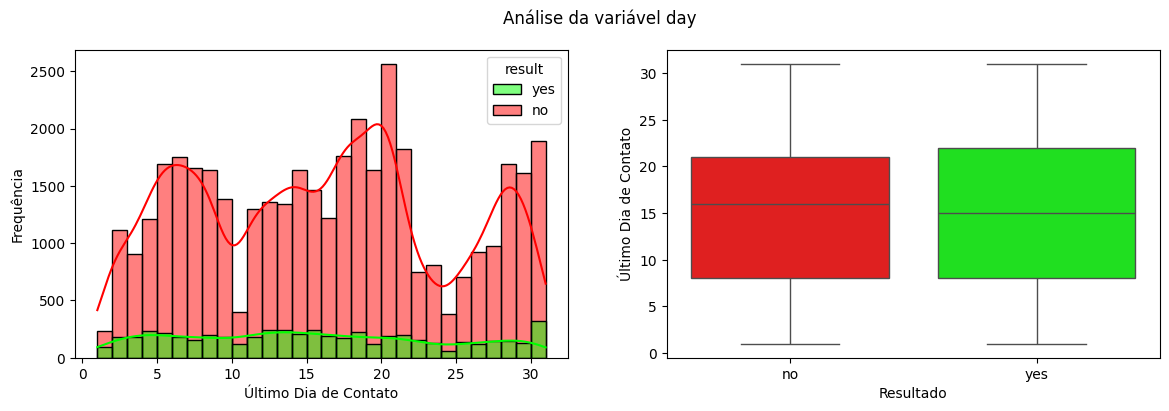

In [30]:
figsize = (14, 4)
variable = 'day'
binwidth = 1
label = 'Último Dia de Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável day, com largura dos bins fixada em 1 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável day, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [31]:
print("Valores nulos:", df['day'].isnull().sum())

Valores nulos: 0


A distribuição apresentada está mais próxima de uma distribuição multimodal.

Do mesmo modo que a variável anterior, a diferença no número de registros de cada classe, acaba dificultando uma análise mais acertiva.

Os valores apresentados estão dentro dos limites de dias do mês. Em geral, não há uma distinção entre o dia de contato e o resultado da campanha. Um destaque especial para os dias 1, 11 e 25, dias com menor quantidade de contatos e para o dia 21, dia com maior quantidade de contatos.

Se a variável trouxesse a informação de qual dia da semana foi realizado o contato (seg, ter, ..., sab) seria uma informação ainda mais relevante para a análise. Podemos utilizar essa informação para dividir o mês em semanas e analisar se houve alguma semana com maior ou menor destaque.

Por fim, observa-se que não há presença de valores nulos.

### month (mês do último contato)

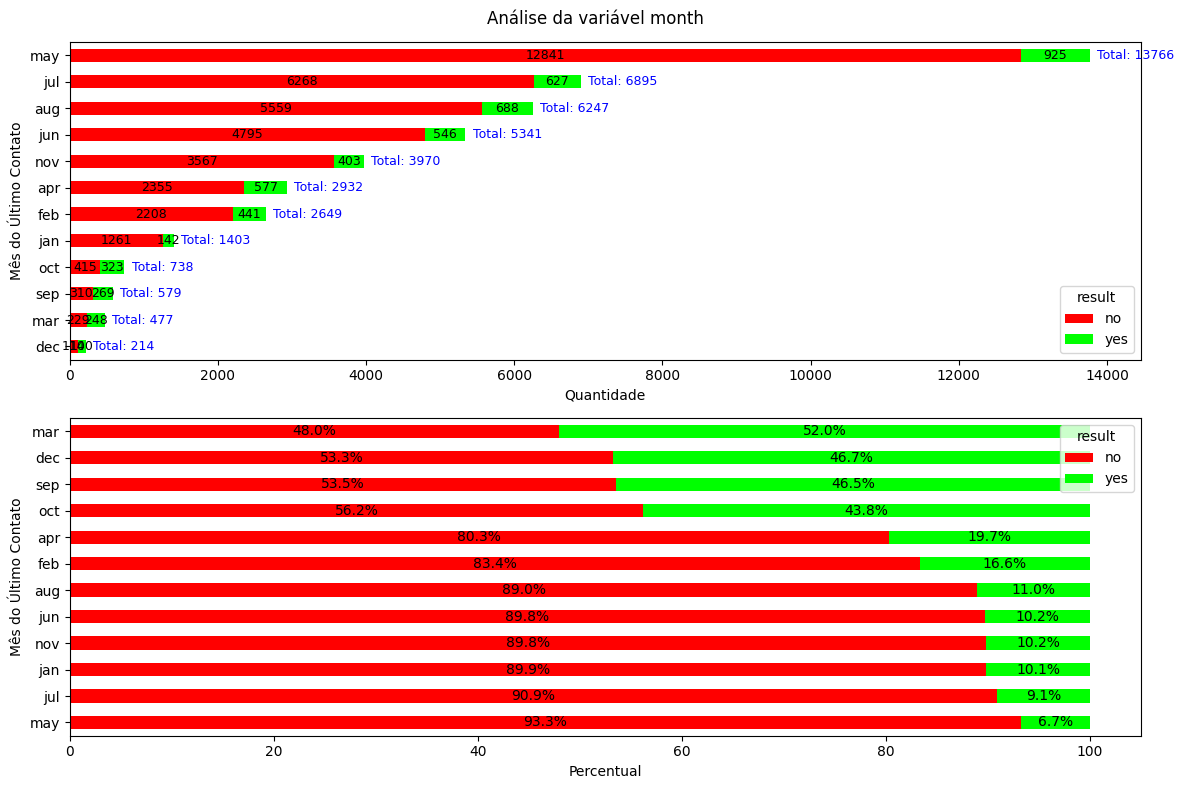

In [32]:
figsize = (12, 8)
variable = 'month'
label = 'Mês do Último Contato'
target = 'result'
plot_barh_by_hue_result(figsize, df, variable, label, target)

**Gráfico superior:** gráfico de barras horizontais da quantidade de registros por mês do último contato, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por mês do último contato.

**Gráfico inferior:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por mês do último contato. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [33]:
print("Valores nulos:", df['month'].isnull().sum())

Valores nulos: 0


O mês de maio foi o mês com a maior quantidade de contatos realizados. No entato, em termos percentuais foi o mês com a menor taxa de aceitação da campanha.

A diferença entre o 1º e o 2º mês de maior contato é extremamente grande. O segundo mês possui praticamente a metade do total de contatos realizados no primeiro mês. Isso é mais um indicativo de desbalanceamento do dataset.

Curiosamente os mêses com menor atividade foram os meses com maior percentual de conversão (março, dezembor, setembro e outubro).

Por fim, não há presença de registros nulos.

 ### duration (duração da ligação)

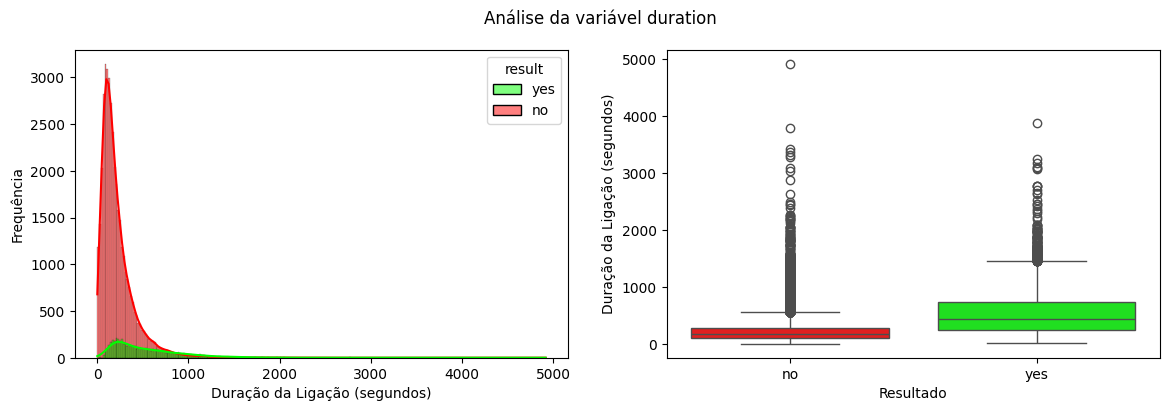

In [34]:
figsize = (14, 4)
variable = 'duration'
binwidth = 20
label = 'Duração da Ligação (segundos)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável duration, com largura dos bins fixada em 10 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável duration, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [35]:
print("Valores nulos:", df['duration'].isnull().sum())

Valores nulos: 0


O histograma indica uma distribuição assimétrica à direita, com presença de possíveis outliers em chamadas superiores a 80 minutos. Esses valores extremos, somados ao desbalanceamento do dataset, dificultam uma análise mais robusta dessa variável.

Como descrito na documentação, a duração da chamada influencia diretamente o resultado da campanha: contatos nulos ou muito curtos tendem a gerar insucesso, enquanto chamadas mais longas estão associadas a maior taxa de sucesso, como evidenciado no boxplot.

Dada a forte correlação com a variável alvo, a duração da chamada não será utilizada em modelos preditivos, para evitar viés. No entanto, ela permanece relevante em análises exploratórias, pois ajuda a compreender o comportamento dos clientes durante a campanha.

Por fim, não foram encontrados valores nulos.

### campaign (número de contatos realizados na campanha)

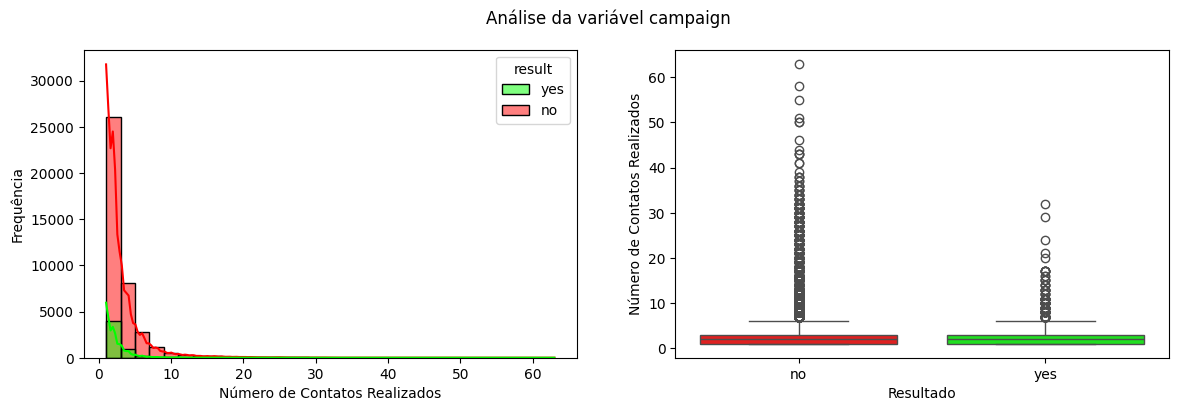

In [36]:
figsize = (14, 4)
variable = 'campaign'
binwidth = 2
label = 'Número de Contatos Realizados'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável campaign, com largura dos bins fixada em 2 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável campaign, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [37]:
print("Valores nulos:", df['campaign'].isnull().sum())

Valores nulos: 0


A variável foi discretizada em faixas de largura 2 para facilitar a visualização. Observa-se que a maioria dos clientes recebeu entre 2 e 5 contatos, enquanto um número ínfimo chegou a ser contactado até 63 vezes, caracterizando outliers que dificultam a interpretação da distribuição.

O boxplot indica que a quantidade de contatos não exerce influência significativa sobre o resultado da campanha, embora haja maior concentração de outliers associados a insucessos.

Por fim, não foram identificados valores nulos nesta variável, o que reforça a consistência dos dados.

### pdays (número de dias desde o contato em campanhas anteriores)

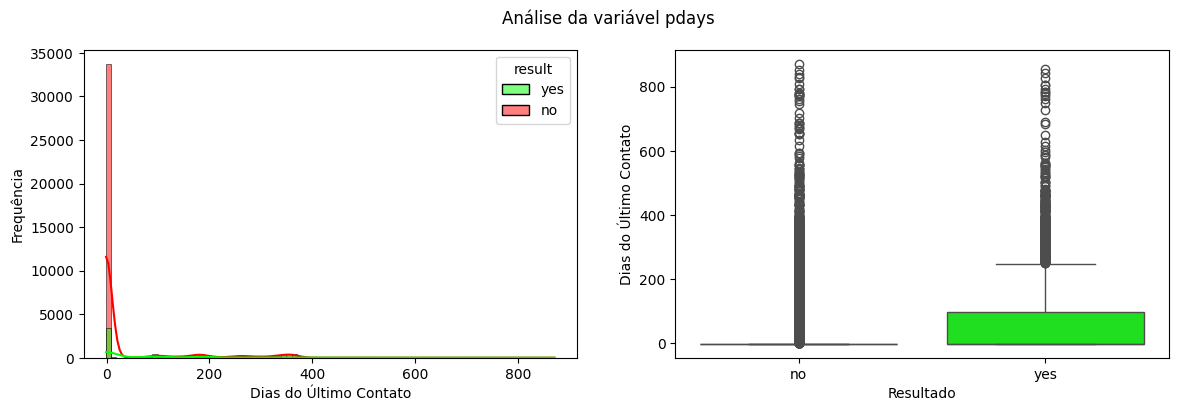

In [38]:
figsize = (14, 4)
variable = 'pdays'
binwidth = 10
label = 'Dias do Último Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável pdays, com largura dos bins fixada em 10 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável pdays, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Ao tentar analisar os dados brutos, observamos um grande desbalanceamento na primeira faixa de valore (de 0 a 10 dias). Vamos agrupar os valores da variável pdays e observar o começo e o final da distribuição.

In [39]:
df.groupby(['pdays', 'result'], as_index=False).size().sort_values(by='pdays').head()

,pdays,result,size
0,-1,no,33570
1,-1,yes,3384
2,1,no,9
3,1,yes,6
4,2,no,35


Observa-se que a grande maioria dos clientes não foram contactados em campanhas anteriores (36.954, cerca de 81%).

In [40]:
df.groupby(['pdays', 'result'], as_index=False).size().sort_values(by='pdays').tail()

,pdays,result,size
909,838,no,1
910,842,yes,1
911,850,no,1
912,854,yes,1
913,871,no,1


Além disso, dentre os que foram contatados anteriormente, alguns apresentam um espaço de tempo muito longo, chegando até 871 dias (mais de dois anos e meio).

Como há uma grande diferença entre os clientes que não foram contactados em campanhas anteriores (pdays = -1) e os que foram contactados anteriormente (pdays > 0), iremos analisar os registros separadamente.

**Analisando os contactados mais de uma vez (pdays > 0):**

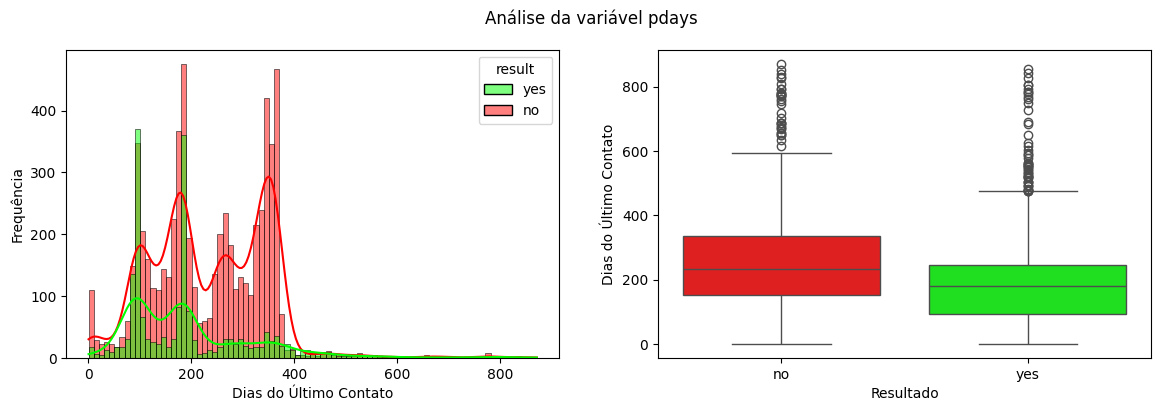

In [41]:
figsize = (14, 4)
variable = 'pdays'
binwidth = 10
label = 'Dias do Último Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df[df.pdays > 0], variable, binwidth, label, target)

No histograma (gráfico da esquerda), observa-se uma distribuição multimodal. Além disso, nota-se que até 200 dias de folga, o comportamento das linhas do resultado são semelhantes, e em alguns momentos, o resultado positivo chega a superar o resultado negativo. Após 200 dias, a linha de sucesso praticamente não cresce mais, e as tentativas de contato, quase sempre resultaram em fracasso.

O boxplot (gráfico da direita) demonstra um pouco esse comportamento, com a maioria dos casos de sucesso estarem antes dos 200 dias. Como visto anteriormente, há alguns registros extremos (com mais de 800 dias de contato) que devem ser analisados e tratados.

**Analisando os contactados apenas uma vez (pdays = -1):**

Para esta análise, preferimos dividir o dataframe em duas partes: contactado em campanha anterior e não contactado. Uma nova coluna booleana, chamada 'contactado_anteriormente', foi criada para realizar a análise. Essa coluna recebe o valor True, caso o número de dias de folga (pdays) seja maior que zero, indicando que houve contato em campanha anterior, e recebe o valor falso, caso pdays seja menor que 0.

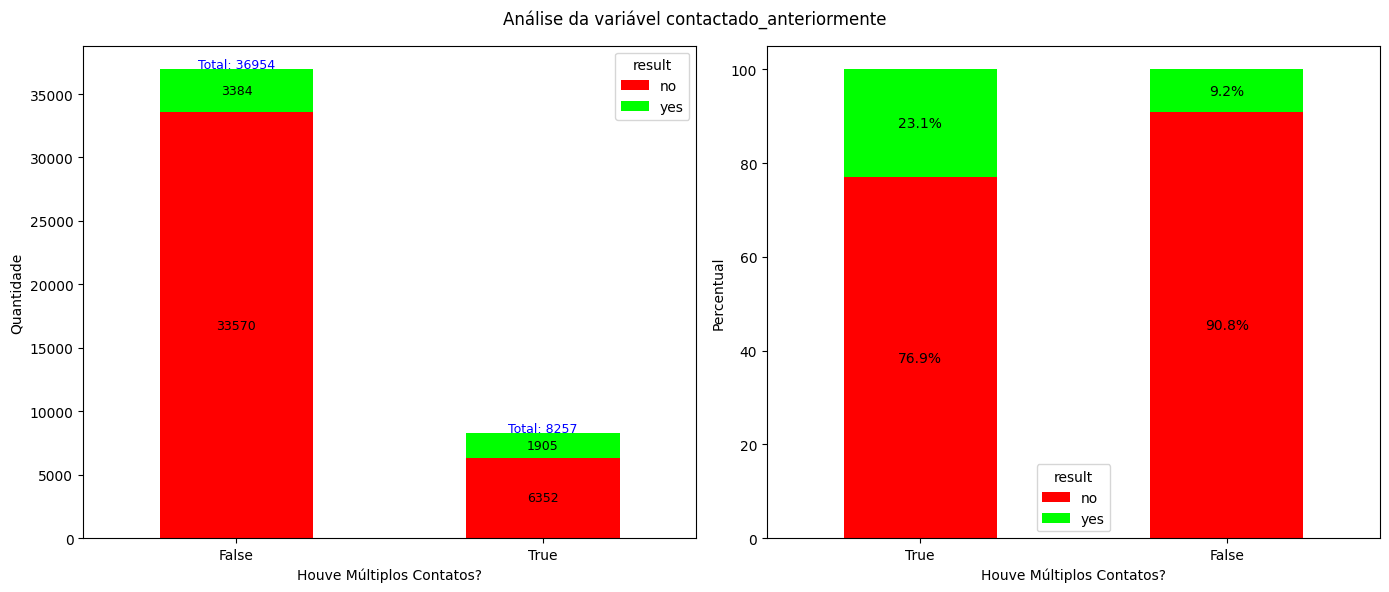

In [42]:
df['contactado_anteriormente'] = df['pdays'] > 0
figsize = (14, 6)
variable = 'contactado_anteriormente'
label = 'Houve Múltiplos Contatos?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por situação de contato anterior, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por situação de contato anterior.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por situação de contato anterior. O gráfico está ordenado da maior taxa de aceitação para a menor.

Embora haja uma diferença significativa entre registros que foram contactados anteriormente (8257) e os que não foram (36954). Observa-se que o percentual de aceitação foi maior entre os que já haviam sido contatados.

Uma proposta de tratamento desta variável, seria discretizar as informações em faixas de valores, como "primeiro contato", "até 10 dias de folga", "até 20 dias de folga", etc.

Verificação da presença de valores nulos:

In [43]:
print("Valores nulos:", df['pdays'].isnull().sum())

Valores nulos: 0


Não há registros nulos.

### previous (número de contatos realizados antes desta campanha)

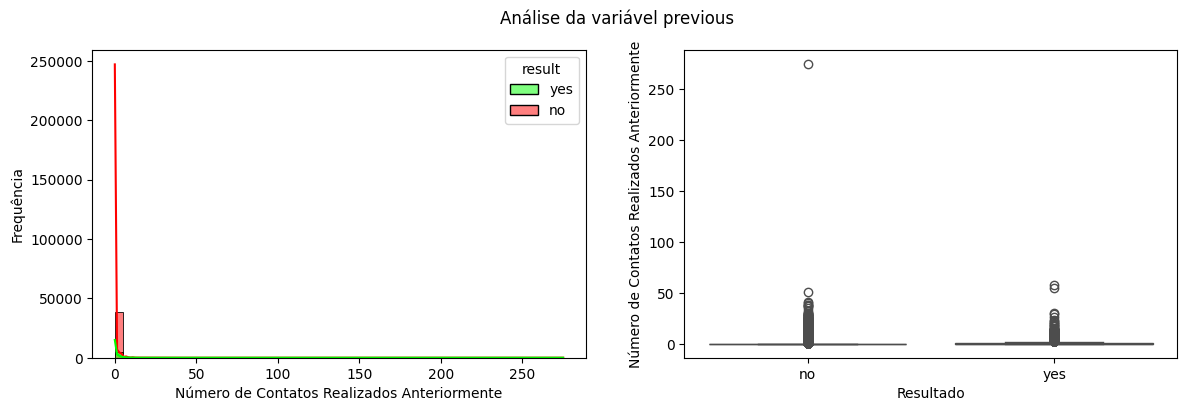

In [44]:
figsize = (14, 4)
variable = 'previous'
binwidth = 5
label = 'Número de Contatos Realizados Anteriormente'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável previous, com largura dos bins fixada em 10 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável previous, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Ao tentar analisar os dados brutos, observamos um grande desbalanceamento na primeira faixa de valore (de 0 a 5 contatos). Vamos agrupar os valores da variável previous e observar o começo e o final da distribuição.

Análise inicial dos valores desta variável:

In [45]:
df.groupby(['previous', 'result'], as_index=False).size().sort_values(by='previous').head()

,previous,result,size
0,0,no,33570
1,0,yes,3384
2,1,no,2189
3,1,yes,583
4,2,no,1650


Há uma grande quantidade de clientes que foram contactados apenas nesta campanha (36.954, cerca de 81%). Coincidentemente, esse valor é igual ao valor de clientes que foram contactados uma única vez na campanha (variável anterior - pdays).

In [46]:
df.groupby(['previous', 'result'], as_index=False).size().sort_values(by='previous').tail()

,previous,result,size
61,41,no,1
62,51,no,1
63,55,yes,1
64,58,yes,1
65,275,no,1


Além disso, dentre os que já foram contatados em campanhas anteriores, um registro se destaca por ter sido contactado 275 vezes, enquanto que o restante dos contatos  .

Da mesma forma que a variável pdays, a grande quantidade de registros de clientes que nunca foram contactados em campanhas anteriores prejudica a análise mais adequada da distribuição dos registros. Desse modo, novamente, iremos dividir a análise entre os que foram contactados em campanhas anteriores e os que foram contactados apenas na campanha atual.

Embora seja parecida com a variável anterior, aparenta ter menos valores extremos.

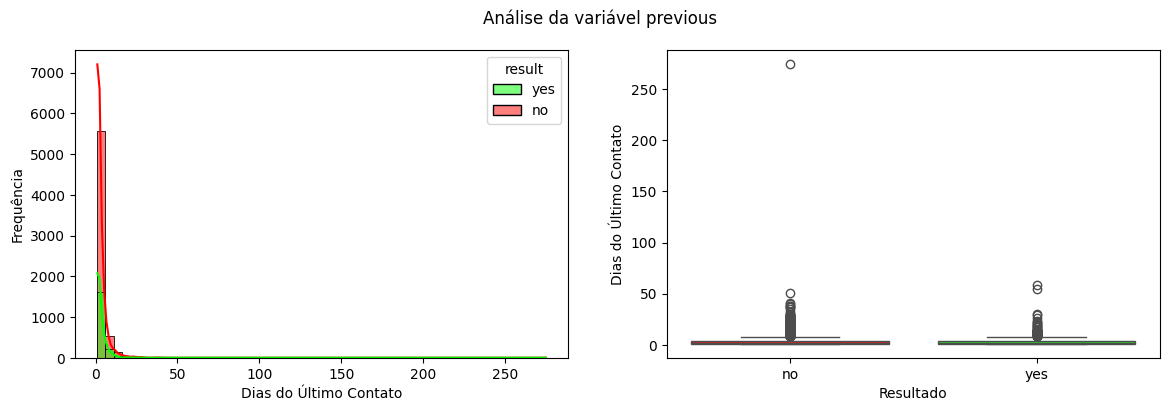

In [47]:
figsize = (14, 4)

variable = 'previous'
binwidth = 5
label = 'Dias do Último Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df[(df.previous > 0)], variable, binwidth, label, target)

Após a remoção dos registros dos que nunca foram contactados em campanhas anteriores, a distibuição ainda permanece assimétrica a direita. Devido a presença de alguns valores extremos, ainda não é possível visualizar tão bem a distribuição. Após o tratamento de outliers poderemos analisar melhor o resultado.

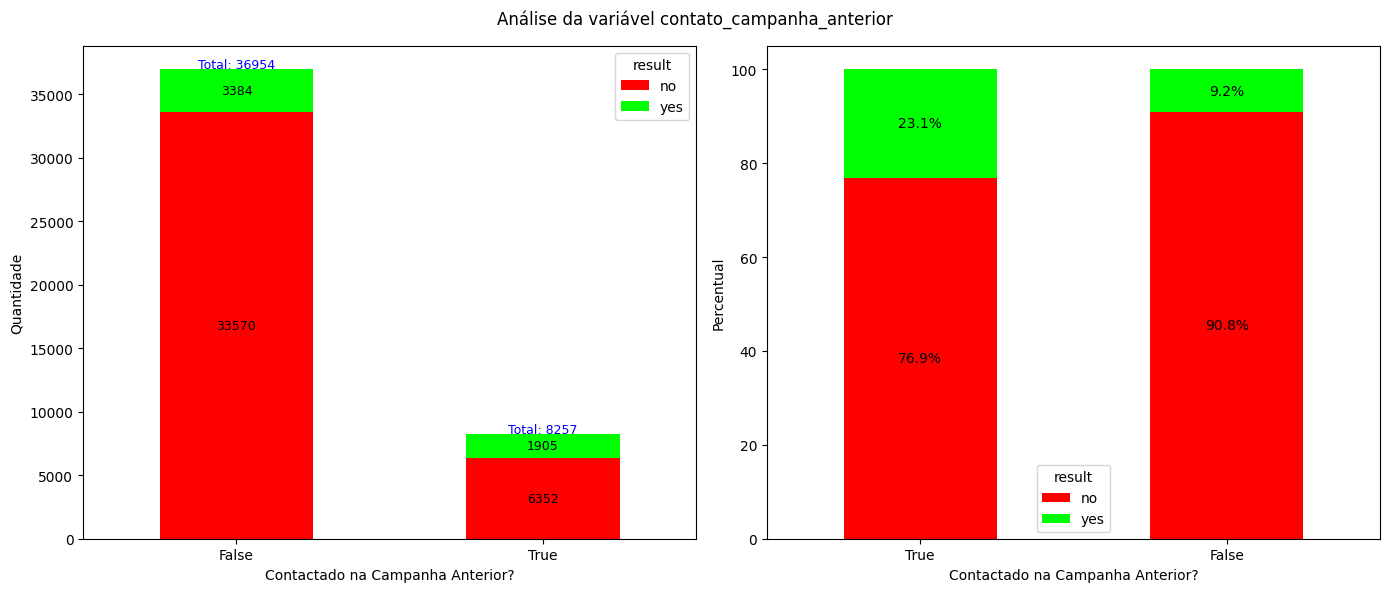

In [48]:
df['contato_campanha_anterior'] = df['previous'] > 0
figsize = (14, 6)
variable = 'contato_campanha_anterior'
label = 'Contactado na Campanha Anterior?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)


Curiosamente, até o percentual de aceitação entre os que foram contactados na campanha anterior e os que não foram, foi igual ao resultado da variável anterior (pdays - dias de folga). Mas como mostramos no gráfico anterior, elas não são iguais, pois possuem distribuições diferentes. Assim, observando os gráficos acima, embora a diferença entre os que foram contactados em campanhas anteriores e os que não foram seja grande, podemos considerar, olhando para os percentuais apresentados, que os clientes que foram contactados em campanhas  anteriores, aderiram melhor a campanha.

Verificação da presença de valores nulos:

In [49]:
print("Valores nulos:", df['previous'].isnull().sum())

Valores nulos: 0


Não há registros nulos.

### poutcome (resultado da campanha anterior)

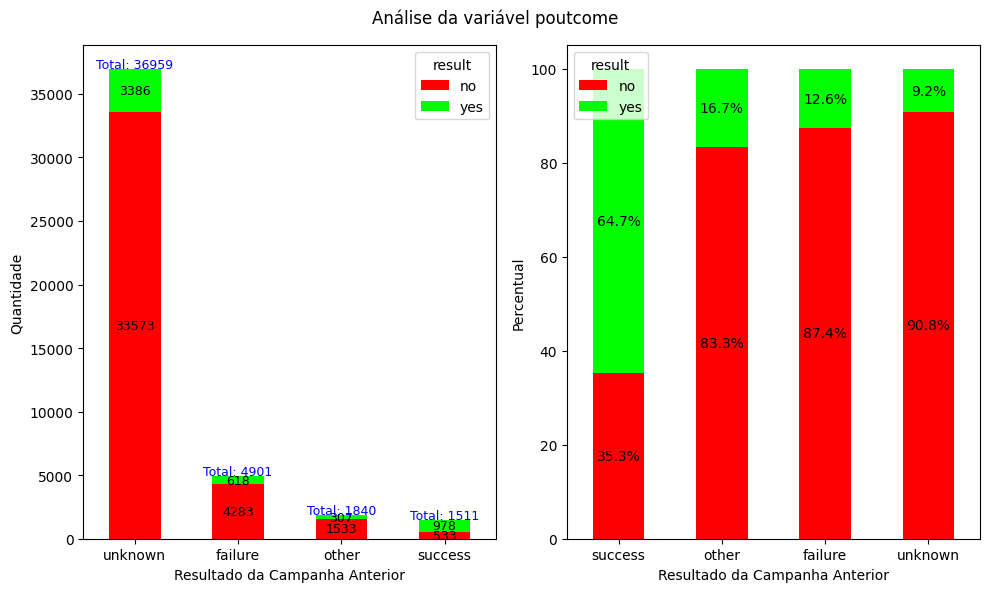

In [50]:
figsize = (10, 6)
variable = 'poutcome'
label = 'Resultado da Campanha Anterior'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por resultado da campanha anterior, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por resultado da campanha anterior.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por resultado da campanha anterior. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [51]:
print("Valores nulos:", df['poutcome'].isnull().sum())

Valores nulos: 0


Esta variável possui uma grande quantidade de valores desconhecidos (36959). No entanto, como visto na variável anterior (previous), 36954 registros não foram contatados em campanhas anteriores, o que pode responder o motivo dessa variável possuir tantos valores nulos. Na etapa de pré-processamento, poderemos analisar se isso é verdadeiro, e criar uma nova categoria para esses registros, como "N/A", ou considerar utilizar o valor 'other'.

Analisando apenas o resultado dos valores não nulo ('failure', 'other' e 'sucess') podemos perceber duas coisas relevantes:
- Dentre as pessoas que aderiram à campanha anterior (sucess), a quantidade pessoas que também aderiram a campanha atual foi maior do que os que não aderiram;
- Dentre as pessoas que recusaram a campanha anterior, a grande maioria também recusou a campanha atual.

Isso mostra que o produto pode ter sido bem apreciado por quem experimentou, mas dificilmente os clientes são convencidos de que é um bom produto.

Por fim, observa-se que não há presença de valores nulos.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

Para analisar a correlação entre as variáveis, iremos adicionar uma nova coluna ao dataframe, convertendo a variável alvo 'result' em uma variável efetivamente binária. Ou seja, o valor 'yes' se tornará 1 e o valor 'no' se tornará 0.

In [52]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df['result_num'] = df['result'].map({'yes': 1, 'no': 0})
variaveis_numericas = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'result_num'
]
df[variaveis_numericas].corr()


Matriz de Correlação:


,age,balance,day,duration,campaign,pdays,previous,result_num
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288,0.025155
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674,0.052838
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710,-0.028348
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203,0.394521
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855,-0.073172
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820,0.103621
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000,0.093236
result_num,0.025155,0.052838,-0.028348,0.394521,-0.073172,0.103621,0.093236,1.000000


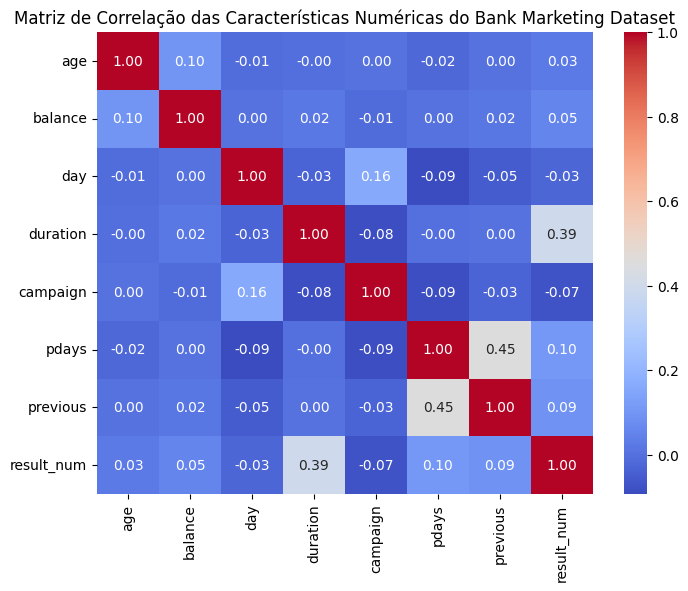

In [53]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df[variaveis_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Bank Marketing Dataset')
plt.show()

Observando o mapa de calor, praticamente todas as variáveis são pouco correlacionadas. As que tem um grau maior de correlação são 'previous' e 'pdays', e 'duration' e 'result_num'.

Conforme indicado na própria documentação do dataset, a variável 'duration' possui forte relação com o resultado da campanha, já que uma duração igual a 0 ou próximo disso, dificilmente gera um resultado positivo.

Já as variáveis 'pdays' (dias do último contato) e 'previous' (contatos realizados na última campanha) possuem uma correlação mais alta, devido ao grande número de registros que foram contactados apenas uma vez na campanha atual e que nunca foram contactados em campanhas anteriores. A variável 'pdays' representa esses registros como -1, e a variável 'previous' representa esses registros como 0. Mas além dessa semelhança, essas variáveis não são correlacionadas.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## Limpeza inicial

Como indicado na análise da variável duration, chamadas com duração muito curta tendem a gerar um resultado negativo. Como queremos analisar a efetividade dos contatos, iremos estabelecer um tempo mínimo de duração das chamadas. Observemos o resultado da campanha para chamadas de até 60 segundos:

In [54]:
df[df.duration < 60].groupby('result').size()

,0
result,
no,4650
yes,9


Como podemos observar, mais de 99% dos casos o resultado é nagtivo. Assim, chamadas que não atingiram pelo menos um minuto de duração serão descartadas.

In [55]:
df_clear = df[df.duration >= 60]

In [56]:
print("Quantidade de registros anterior:", len(df))
print("Quantidade de registros após limpeza:", len(df_clear))

Quantidade de registros anterior: 45211
Quantidade de registros após limpeza: 40552


Além disso, iremos descartar as colunas 'multiplos_contatos','contato_campanha_anterior' e 'result_num' que foram criadas apenas para análises temporárias dos dados.

In [57]:
df_droped = df_clear.drop(columns=['contactado_anteriormente', 'contato_campanha_anterior', 'result_num'])

## Renomear colunas

In [58]:
df_droped.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'result'],
      dtype='object')

Para facilitar o entendimento do tipo de dado armazenado da coluna, iremos renomear algumas colunas.

In [59]:
df_renamed = df_droped.rename(columns={
    'age': 'client_age',
    'job': 'client_job',
    'marital': 'client_marital_status',
    'education': 'client_education_level',
    'default': 'client_financial_default',
    'balance': 'client_average_annual_balance',
    'housing': 'client_housing_loan',
    'loan': 'client_personal_loan',
    'contact': 'contact_type',
    'day': 'contact_day_of_month',
    'month': 'contact_month',
    'duration': 'contact_duration',
    'campaign': 'number_contacts_campaign',
    'pdays': 'days_last_contact',
    'previous': 'number_contacts_previous_campaign',
    'poutcome': 'result_previous_campaign',
    'result': 'result_campaign'
})

## Tratamento de Valores Nulos
Vamos verificar a presença de valoes nulos no dataset:

In [60]:
df_not_nulls = df_renamed.copy()

In [61]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Bank Marketing:")
df_renamed.isnull().sum()

Valores nulos no dataset Bank Marketing:


,0
client_age,0
client_job,0
client_marital_status,0
client_education_level,0
client_financial_default,0
client_average_annual_balance,0
client_housing_loan,0
client_personal_loan,0
contact_type,0
contact_day_of_month,0


Como observado, nenhuma das colunas possuem valores nulos.

No caso da variável result_previous_campaign, conforme observado na análise exploratória, o número de valores desconhecidos (36959) é muito semelhante ao de clientes que não foram contactados em campanhas anteriores (36954). Ou seja, se o cliente não foi contatado em campanhas anteriores, não pode haver o resultado da campanha anterior, então, nesse caso, a categoria aplicada deverá ser "N/A" (não se aplica). Para os demais casos, devemos aplicar a categoria 'other' e não 'unknow'.

In [62]:
df_not_nulls.loc[(
  df_not_nulls.result_previous_campaign == 'unknown')
  & (df_not_nulls.number_contacts_previous_campaign == 0),
  'result_previous_campaign'] = 'N/A'
df_not_nulls.loc[(
  df_not_nulls.result_previous_campaign == 'unknown')
  & (df_not_nulls.number_contacts_previous_campaign > 0),
  'result_previous_campaign'] = 'other'

## Tratamento de outliers

A presença de valores extremos pode representar erros ou até mesmo um comportamento natural dos dados. A seguir, iremos analisar as variáveis os valores extremos das variáveis numéricas do dataset.

In [63]:
df_without_outliers = df_not_nulls.copy()

Como todas as distribuições das variáveis numéricas analisadas não seguem a distribuição normal, iremos avaliar a presença de outliers a partir do intervalo interquartil (IQR).

Cálculo pelo IQR:

In [64]:
def recuperar_outliers_IQR(df, variavel):
  Q1 = df[variavel].quantile(0.25)
  Q3 = df[variavel].quantile(0.75)
  IQR = Q3 - Q1

  # Definindo limites
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print("Limite inferior:", lower_bound)
  print("Limite superior:", upper_bound)

  # Recuperando registros outliers
  return df[(df[variavel] < lower_bound) | (df[variavel] > upper_bound)]


### Análise dos outliers por variável


In [65]:
for variavel in ['client_age', 'client_average_annual_balance', 'contact_duration', 'number_contacts_campaign', 'days_last_contact', 'number_contacts_previous_campaign']:
  print(f"Análise dos outliers da variável {variavel} pelo IQR:")
  outliers_IQR = recuperar_outliers_IQR(df_without_outliers, variavel)
  print("Total de registros considerados outliers:", outliers_IQR[variavel].count())
  print("Menor valor encontrado: ", outliers_IQR[variavel].min())
  print("Maior valor encontrado:", outliers_IQR[variavel].max())
  print("-"*20)

Análise dos outliers da variável client_age pelo IQR:
Limite inferior: 10.5
Limite superior: 70.5
Total de registros considerados outliers: 483
Menor valor encontrado:  71
Maior valor encontrado: 95
--------------------
Análise dos outliers da variável client_average_annual_balance pelo IQR:
Limite inferior: -1969.5
Limite superior: 3482.5
Total de registros considerados outliers: 4223
Menor valor encontrado:  -8019
Maior valor encontrado: 102127
--------------------
Análise dos outliers da variável contact_duration pelo IQR:
Limite inferior: -202.0
Limite superior: 670.0
Total de registros considerados outliers: 2948
Menor valor encontrado:  671
Maior valor encontrado: 4918
--------------------
Análise dos outliers da variável number_contacts_campaign pelo IQR:
Limite inferior: -2.0
Limite superior: 6.0
Total de registros considerados outliers: 2041
Menor valor encontrado:  7
Maior valor encontrado: 63
--------------------
Análise dos outliers da variável days_last_contact pelo IQR:
L

Para a variável client_age, observamos que os valores apontados como outliers não se tratam de erros, pois estão dentro de um limite aceitável de tempo de vida humana. Assim, não iremos aplicar nenhum tratamento em cima dessa variável.

Para as demais variável, observamos uma quantidade significativa de registros apontados como outliers e precisará ser feita uma análise mais detalhada desses valores.

### client_average_annual_balance

A seguir, iremos analisar com mais detalhes a distribuição da variável client_average_annual_balance:

In [66]:
Q1 = df_without_outliers['client_average_annual_balance'].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['client_average_annual_balance'].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 75.0
Q3: 1438.0
IQR: 1363.0
Lower bound: -1969.5
Upper bound: 3482.5


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -1969 ou superior a 3482. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [67]:
lowers = df_without_outliers[(df_without_outliers['client_average_annual_balance'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['client_average_annual_balance'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 15
Número de valores extremos superiores: 4208


Apenas 15 registros seriam eliminados se aplicássemos a remoção de registros abaixo do limite inferior. Esta não é uma quantidade considerável de registros, comparado a quantidade total do dataset. No entanto, 4208 registros seriam eliminados se removessemos os registros a cima do limite superior. 4208 registros é uma quantidade significativamente maior e precisa ser analisada mais de perto para entender a natureza desses registros.

Vejamos os registros acima do limite superior:

In [68]:
uppers['client_average_annual_balance'].sort_values()

,client_average_annual_balance
16911,3485
29347,3485
11157,3485
21226,3485
22065,3486
...,...
41693,71188
43393,81204
42558,81204
26227,98417


O intervalo de valores é consideravelmente grande (de 3.485 a 102.127). Como se trata de saldos anuais de contas bancárias, não podemos considerar simplesmente como outliers, pois pode haver clientes consideravelmente mais ricos que outros. Vejamos a distribuição desses valores:

Vejamos a distribuição dos registros acima do limite superior:

In [69]:
print("25% dos valores extremos superiores:", uppers['client_average_annual_balance'].quantile(0.25))
print("50% dos valores extremos superiores:", uppers['client_average_annual_balance'].quantile(0.50))
print("75% dos valores extremos superiores:", uppers['client_average_annual_balance'].quantile(0.75))
print("90% dos valores extremos superiores:", uppers['client_average_annual_balance'].quantile(0.9))

25% dos valores extremos superiores: 4359.0
50% dos valores extremos superiores: 5640.0
75% dos valores extremos superiores: 8304.0
90% dos valores extremos superiores: 13014.0


Observamos que os valores mais extremos se encontram depois de 90% dos registros considerados como outliers. A partir de 90%, temos valores entre 13.014 e 102.127. Um analista da área poderia trazer um maior entendimento sobre esses valores e validar se são valores aceitáveis ou se são valores muito distantes da realidade. Mas, para esse trabalho, iremos considerar que os registros acima de 90% são considerados outliers. Os demais registros serão considerados como válidos.

Para minimizar a presença desses outliers, esta variável será discretizada na etapa seguinte.

Aplicando o novo limite superior:

In [70]:
upper_bound = uppers['client_average_annual_balance'].quantile(0.9)
uppers['client_average_annual_balance'][uppers.client_average_annual_balance > upper_bound]

,client_average_annual_balance
334,24598
446,45248
920,58544
2065,18722
2343,24299
...,...
44861,26306
44874,17458
45019,16873
45118,14204


De 4208 reduzimos para apenas 420 registros que serão removidos do dataset.

In [71]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.client_average_annual_balance >= lower_bound) &
    (df_without_outliers.client_average_annual_balance <= upper_bound)
]

In [72]:
print("Total de registros no dataframe restante:", len(df_without_outliers))

Total de registros no dataframe restante: 40117


A distribuição anterior da variável client_average_annual_balance era:

---



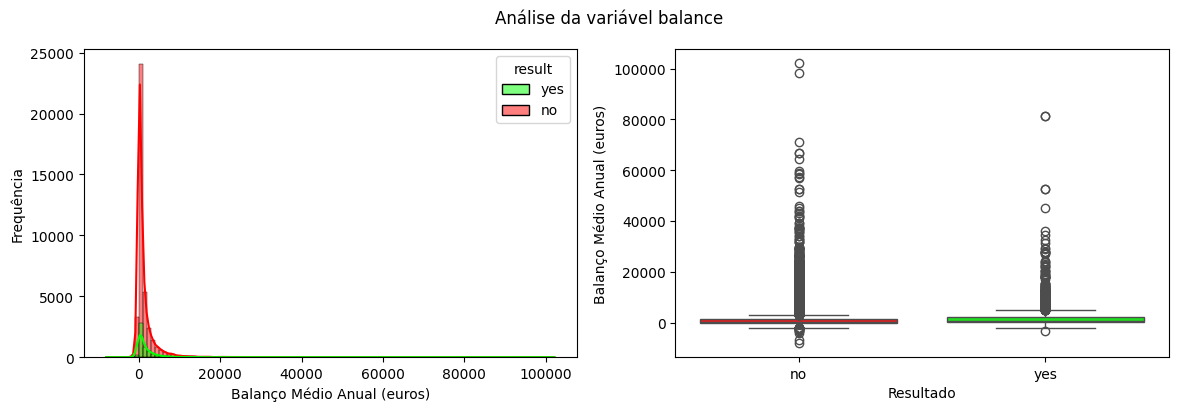

In [73]:
figsize = (14, 4)
variable = 'balance'
binwidth = 1000
label = 'Balanço Médio Anual (euros)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

E agora passa a ser:

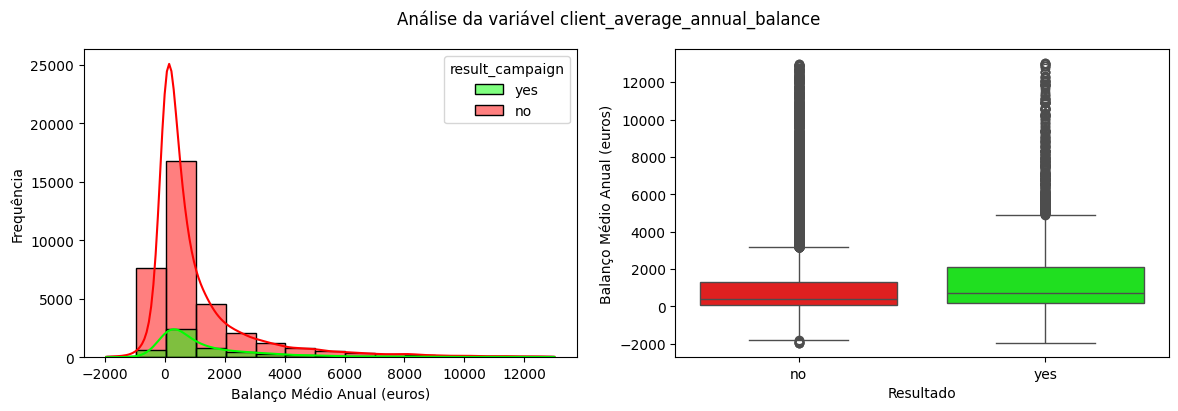

In [74]:
figsize = (14, 4)
variable = 'client_average_annual_balance'
binwidth = 1000
label = 'Balanço Médio Anual (euros)'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers, variable, binwidth, label, target)

### contact_duration

A seguir, iremos analisar com mais detalhes a distribuição da variável contact_duration:

In [75]:
Q1 = df_without_outliers['contact_duration'].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['contact_duration'].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 125.0
Q3: 342.0
IQR: 217.0
Lower bound: -200.5
Upper bound: 667.5


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -2 ou superior a 6. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [76]:
lowers = df_without_outliers[(df_without_outliers['contact_duration'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['contact_duration'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 0
Número de valores extremos superiores: 2944


Nenhum registro está abaixo do limite inferior. No entanto, 2944 registros seriam eliminados se removessemos os registros a cima do limite superior. 2944 registros é uma quantidade significativamente maior e precisa ser analisada mais de perto para entender a natureza desses registros.

Vejamos os registros acima do limite superior:

In [77]:
uppers['contact_duration'].sort_values()

,contact_duration
7773,668
7431,668
13532,668
10966,668
37896,668
...,...
2386,3366
19639,3422
44602,3785
9947,3881


O intervalo de valores vai de 668 segundos (aproximadamente 11 minutos) até 4918 segundos (cerca de 81 minutos), uma diferença consideravelmente grande. Vejamos a distribuição desses valores:

In [78]:
print("25% dos valores extremos superiores:", uppers['contact_duration'].quantile(0.25))
print("50% dos valores extremos superiores:", uppers['contact_duration'].quantile(0.50))
print("75% dos valores extremos superiores:", uppers['contact_duration'].quantile(0.75))
print("90% dos valores extremos superiores:", uppers['contact_duration'].quantile(0.9))

25% dos valores extremos superiores: 756.0
50% dos valores extremos superiores: 885.0
75% dos valores extremos superiores: 1118.0
90% dos valores extremos superiores: 1419.7000000000003


Observamos que os valores mais extremos se encontram depois de 90% dos registros considerados como outliers. A partir de 90%, temos valores entre 1419 segundos (cerca de 24 minutos) e 4918 segundos (cerca de 81 minutos). Um funcionário do banco saberia informar se são números distantes da duração de um contato com os clientes. Mas, para esse trabalho, iremos considerar que os registros acima de 90% são considerados outliers. Os demais registros serão considerados como válidos.

Para minimizar a presença desses outliers, esta variável será discretizada na etapa seguinte.

Aplicando o novo limite superior:

In [79]:
upper_bound = uppers['contact_duration'].quantile(0.9)
uppers['contact_duration'][uppers.contact_duration > upper_bound].sort_values()

,contact_duration
29313,1420
33479,1422
16864,1422
11865,1422
43148,1422
...,...
2386,3366
19639,3422
44602,3785
9947,3881


De 2944 reduzimos para apenas 295 registros que serão removidos do dataset.

In [80]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.contact_duration >= lower_bound) &
    (df_without_outliers.contact_duration <= upper_bound)
]

In [81]:
print("Total de registros no dataframe restante:", len(df_without_outliers))

Total de registros no dataframe restante: 39822


A distribuição anterior da variável number_contacts_campaign era:

---



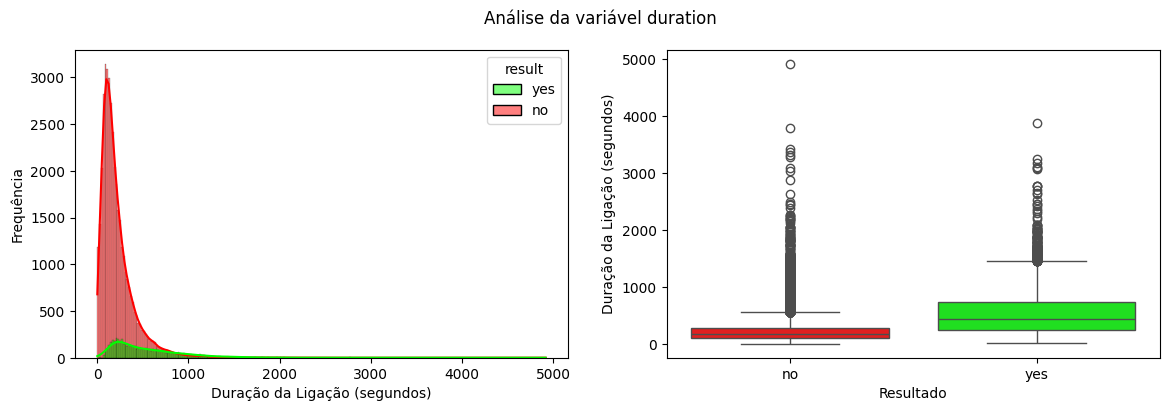

In [82]:
figsize = (14, 4)
variable = 'duration'
binwidth = 20
label = 'Duração da Ligação (segundos)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

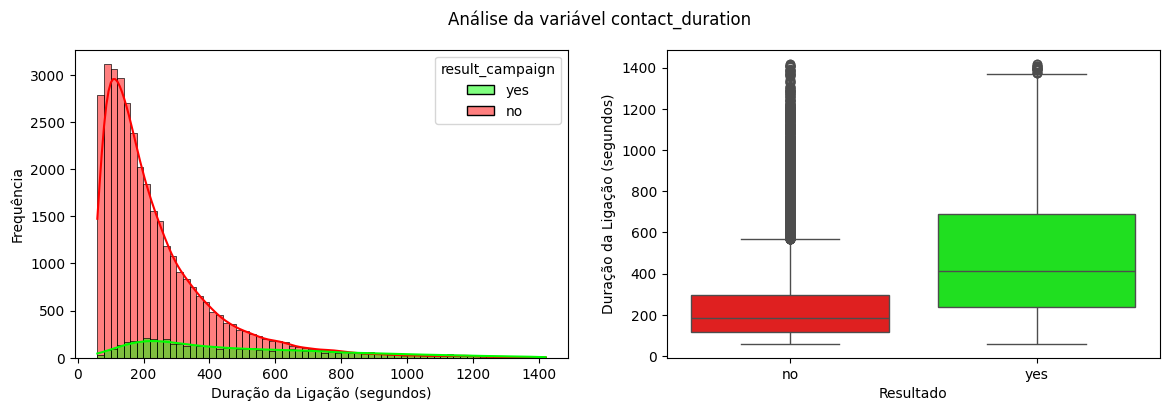

In [83]:
figsize = (14, 4)
variable = 'contact_duration'
binwidth = 20
label = 'Duração da Ligação (segundos)'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers, variable, binwidth, label, target)

Observando os gráficos, vemos que a partir de 200 segundos de ligação, a campanha tende ser positiva.

### number_contacts_campaign

A seguir, iremos analisar com mais detalhes a distribuição da variável number_contacts_campaign:

In [84]:
Q1 = df_without_outliers['number_contacts_campaign'].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['number_contacts_campaign'].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower bound: -2.0
Upper bound: 6.0


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -2 ou superior a 6. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [85]:
lowers = df_without_outliers[(df_without_outliers['number_contacts_campaign'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['number_contacts_campaign'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 0
Número de valores extremos superiores: 1999


Nenhum registro está abaixo do limite inferior. No entanto, 1999 registros seriam eliminados se removessemos os registros a cima do limite superior. 1999 registros é uma quantidade significativamente maior e precisa ser analisada mais de perto para entender a natureza desses registros.

Vejamos os registros acima do limite superior:

In [86]:
uppers['number_contacts_campaign'].sort_values()

,number_contacts_campaign
2684,7
2290,7
1579,7
45056,7
1469,7
...,...
5459,50
18713,50
4299,51
5073,55


O intervalo de valores vai de 1 até 55 contatos, uma diferença consideravelmente grande. Vejamos a distribuição desses valores:

In [87]:
print("25% dos valores extremos superiores:", uppers['number_contacts_campaign'].quantile(0.25))
print("50% dos valores extremos superiores:", uppers['number_contacts_campaign'].quantile(0.50))
print("75% dos valores extremos superiores:", uppers['number_contacts_campaign'].quantile(0.75))
print("90% dos valores extremos superiores:", uppers['number_contacts_campaign'].quantile(0.9))

25% dos valores extremos superiores: 7.0
50% dos valores extremos superiores: 9.0
75% dos valores extremos superiores: 12.0
90% dos valores extremos superiores: 16.0


Observamos que os valores mais extremos se encontram depois de 90% dos registros considerados como outliers. A partir de 90%, temos valores entre 16 e 55. Um funcionário do banco saberia informar se são números distantes da quantidade de vezes que os clientes são contactados em uma campanha. Mas, para esse trabalho, iremos considerar que os registros acima de 90% são considerados outliers. Os demais registros serão considerados como válidos.

Para minimizar a presença desses outliers, esta variável será discretizada na etapa seguinte.

Aplicando o novo limite superior:

In [88]:
upper_bound = uppers['number_contacts_campaign'].quantile(0.9)
uppers['number_contacts_campaign'][uppers.number_contacts_campaign > upper_bound].sort_values()

,number_contacts_campaign
3813,17
3957,17
3949,17
5631,17
7582,17
...,...
5459,50
18713,50
4299,51
5073,55


De 2944 reduzimos para apenas 178 registros que serão removidos do dataset.

In [89]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.number_contacts_campaign >= lower_bound) &
    (df_without_outliers.number_contacts_campaign <= upper_bound)
]

In [90]:
print("Total de registros no dataframe restante:", len(df_without_outliers))

Total de registros no dataframe restante: 39644


A distribuição anterior da variável number_contacts_campaign era:

---



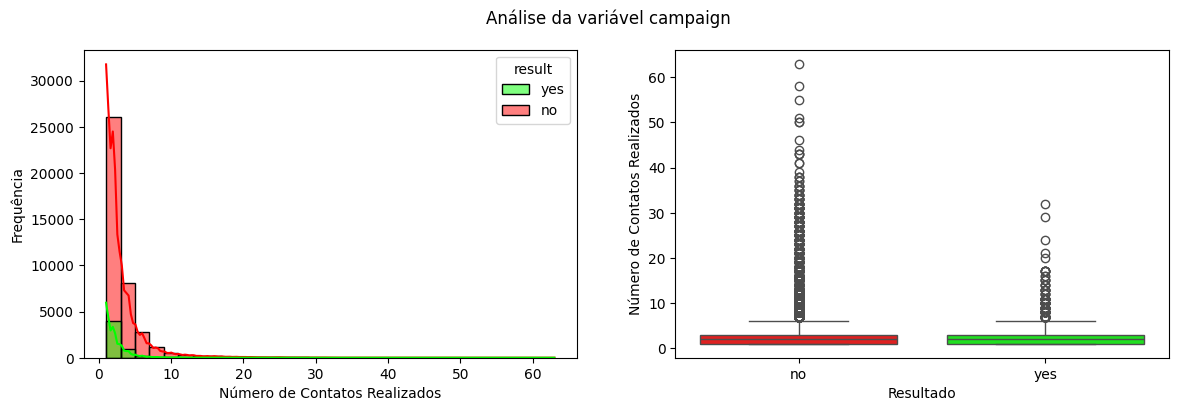

In [91]:
figsize = (14, 4)
variable = 'campaign'
binwidth = 2
label = 'Número de Contatos Realizados'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

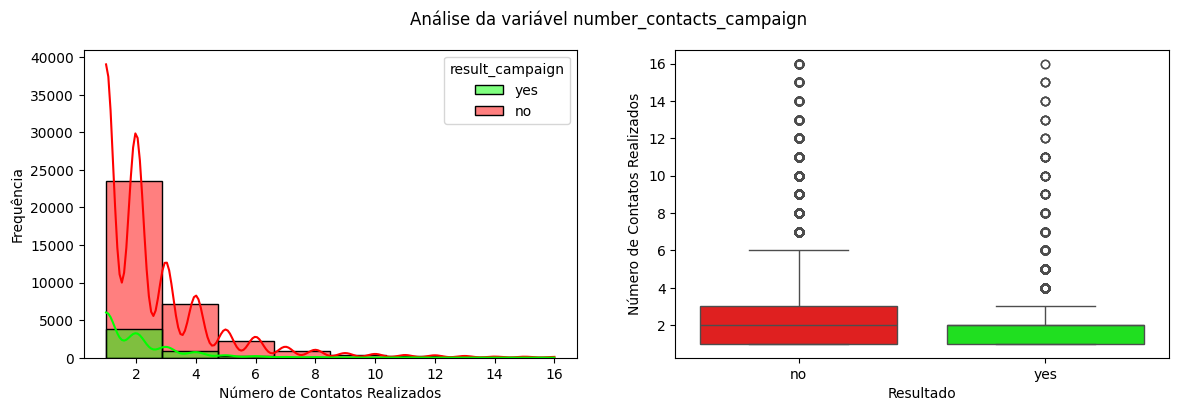

In [92]:
figsize = (14, 4)
variable = 'number_contacts_campaign'
binwidth = 2
label = 'Número de Contatos Realizados'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers, variable, binwidth, label, target)

### days_last_contact

A seguir, iremos analisar com mais detalhes a distribuição da variável number_contacts_campaign:

In [93]:
Q1 = df_without_outliers['days_last_contact'][df_without_outliers.days_last_contact > 0].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['days_last_contact'][df_without_outliers.days_last_contact > 0].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 126.0
Q3: 323.0
IQR: 197.0
Lower bound: -169.5
Upper bound: 618.5


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -169.5 ou superior a 618.5. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [94]:
lowers = df_without_outliers[(df_without_outliers['days_last_contact'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['days_last_contact'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 0
Número de valores extremos superiores: 32


Nenhum registro está abaixo do limite inferior. E, diferente dos registros anteriores, apenas 32 registros seriam eliminados se removessemos os registros a cima do limite superior. Vejamos os registros acima do limite superior:

In [95]:
uppers['days_last_contact'].sort_values().head()

,days_last_contact
43404,626
43586,633
43507,648
43884,651
44711,655


In [96]:
uppers['days_last_contact'].sort_values().tail()

,days_last_contact
44530,828
44698,831
44858,842
44829,854
45146,871


Aplicando limites:

In [97]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.days_last_contact >= lower_bound) &
    (df_without_outliers.days_last_contact <= upper_bound)
]

In [98]:
print("Total de registros no dataframe restante:", len(df_without_outliers))

Total de registros no dataframe restante: 39612


A distribuição anterior da variável days_last_contact era:

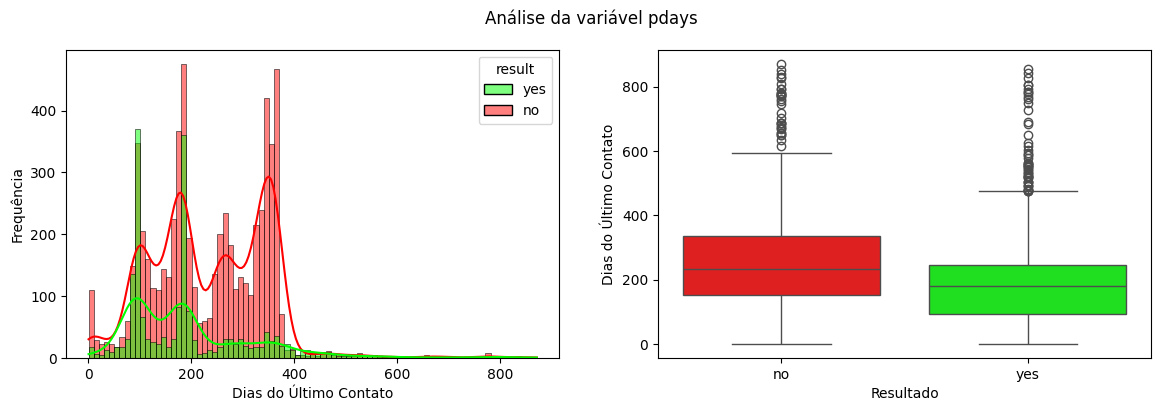

In [99]:
figsize = (14, 4)
variable = 'pdays'
binwidth = 10
label = 'Dias do Último Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df[df.pdays > 0], variable, binwidth, label, target)

E agora passa a ser:

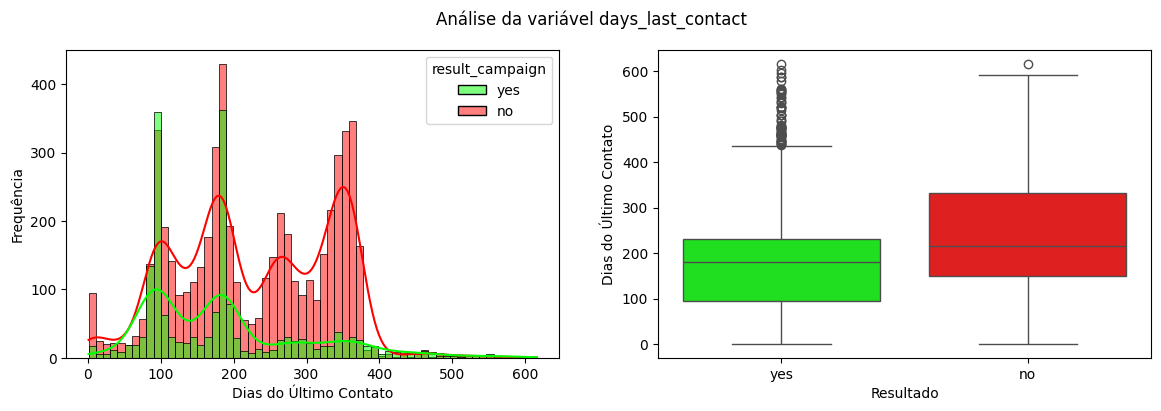

In [100]:
figsize = (14, 4)
variable = 'days_last_contact'
binwidth = 10
label = 'Dias do Último Contato'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers[df_without_outliers.days_last_contact > 0], variable, binwidth, label, target)

Como poucos registros foram considerados como outliers, não tivemos uma diferença tão grande entre os gráficos.

### number_contacts_previous_campaign

A seguir, iremos analisar com mais detalhes a distribuição da variável number_contacts_previous_campaign:

In [101]:
Q1 = df_without_outliers['number_contacts_previous_campaign'][df_without_outliers.number_contacts_previous_campaign > 0].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['number_contacts_previous_campaign'][df_without_outliers.number_contacts_previous_campaign > 0].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 1.0
Q3: 4.0
IQR: 3.0
Lower bound: -3.5
Upper bound: 8.5


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -3.5 ou superior a 8.5. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [102]:
lowers = df_without_outliers[(df_without_outliers['number_contacts_previous_campaign'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['number_contacts_previous_campaign'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 0
Número de valores extremos superiores: 363


Nenhum registro está abaixo do limite inferior. 363 registros seriam eliminados se removessemos os registros a cima do limite superior. Mesmo sendo poucos registros, precisamos avaliar melhor o resultado.

In [103]:
uppers['number_contacts_previous_campaign'].sort_values()

,number_contacts_previous_campaign
27177,9
24609,9
28185,9
44779,9
28384,9
...,...
42422,37
42611,40
28886,51
38326,58


O intervalo de valores vai de 9 até 275 contatos, uma diferença consideravelmente grande, embora, apenas um registro seja 275. Iremos remover apenas esse registro para avaliar a distribuição.

In [104]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.number_contacts_previous_campaign < 275)
]

In [105]:
Q1 = df_without_outliers['number_contacts_previous_campaign'][df_without_outliers.number_contacts_previous_campaign > 0].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['number_contacts_previous_campaign'][df_without_outliers.number_contacts_previous_campaign > 0].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)
lowers = df_without_outliers[(df_without_outliers['number_contacts_previous_campaign'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['number_contacts_previous_campaign'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Q1: 1.0
Q3: 4.0
IQR: 3.0
Lower bound: -3.5
Upper bound: 8.5
Número de valores extremos inferiores: 0
Número de valores extremos superiores: 362


Mesmo removendo o valor mais extremo, não houve mudança na análise dos outliers.

Analisando a distribuição:

In [106]:
print("25% dos valores extremos superiores:", uppers['number_contacts_previous_campaign'].quantile(0.25))
print("50% dos valores extremos superiores:", uppers['number_contacts_previous_campaign'].quantile(0.50))
print("75% dos valores extremos superiores:", uppers['number_contacts_previous_campaign'].quantile(0.75))
print("90% dos valores extremos superiores:", uppers['number_contacts_previous_campaign'].quantile(0.9))

25% dos valores extremos superiores: 10.0
50% dos valores extremos superiores: 11.0
75% dos valores extremos superiores: 15.0
90% dos valores extremos superiores: 20.0


Observamos que os valores mais extremos se encontram depois de 90% dos registros considerados como outliers. A partir de 90%, temos valores entre 20 e 58. Um funcionário do banco saberia informar se são números distantes da quantidade de vezes que os clientes são contactados em uma campanha. Mas, para esse trabalho, iremos considerar que os registros acima de 90% são considerados outliers. Os demais registros serão considerados como válidos.

Para minimizar a presença desses outliers, esta variável será discretizada na etapa seguinte.

Aplicando novo limite superior:

In [107]:
upper_bound = uppers['number_contacts_previous_campaign'].quantile(0.9)
uppers['number_contacts_previous_campaign'][uppers.number_contacts_previous_campaign > upper_bound].sort_values()

,number_contacts_previous_campaign
24624,21
37978,21
39925,21
31727,22
37151,22
36834,22
38770,22
44147,22
34944,23
34691,23


In [108]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.number_contacts_previous_campaign >= lower_bound) &
    (df_without_outliers.number_contacts_previous_campaign <= upper_bound)
]

In [109]:
print("Total de registros no dataframe restante:", len(df_without_outliers))

Total de registros no dataframe restante: 39576


A distribuição anterior da variável era:

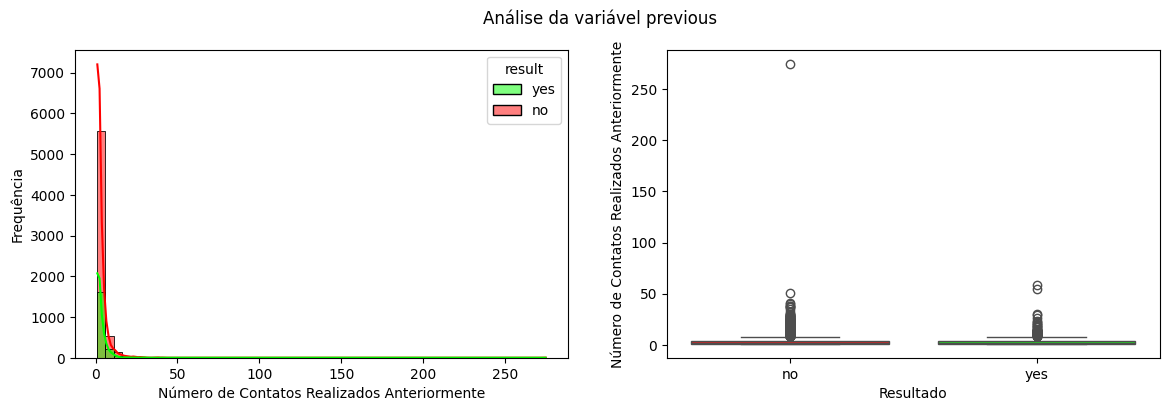

In [110]:
figsize = (14, 4)
variable = 'previous'
binwidth = 5
label = 'Número de Contatos Realizados Anteriormente'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df[df.previous > 0], variable, binwidth, label, target)

E passou a ser:

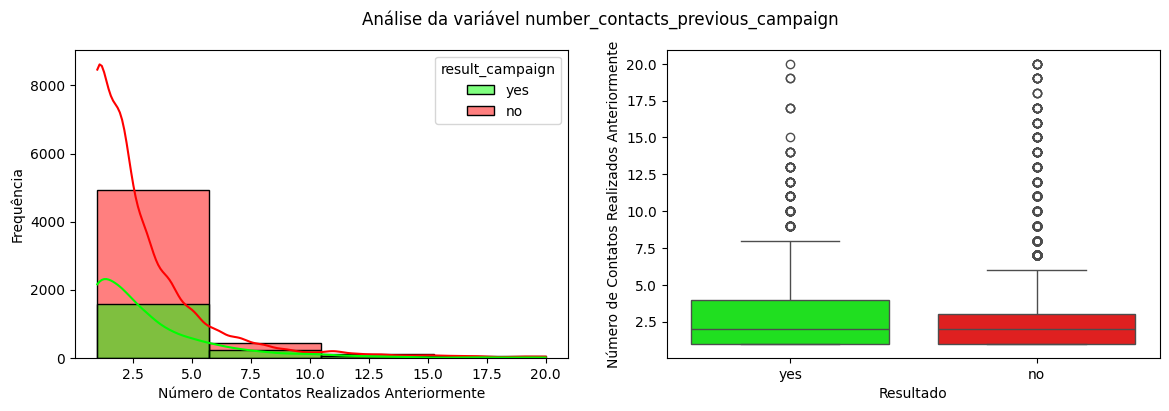

In [111]:
figsize = (14, 4)
variable = 'number_contacts_previous_campaign'
binwidth = 5
label = 'Número de Contatos Realizados Anteriormente'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers[df_without_outliers.number_contacts_previous_campaign > 0], variable, binwidth, label, target)

## Discretizar colunas contínuas

Como introduzido na etapa anterior, para diminuir o impacto dos outliers iremos discretizar as variáveis numéricas. Esta etapa também será fundamental para aplicar um rebalanceamento do dataset, buscando reduzir as diferenças entre as categorias.

In [112]:
df_discretizado = df_without_outliers.copy()

### client_age

Para a variável client_age iremos discretizar seguindo valores pré-estabelecidos de faixa etária: 0-17 (Criança/Adolescente), 18-24 (Jovem) 35-39 (Adulto), 40-59 (Meia-idade), 100 (Idoso).

In [113]:
# age (idade): por faixa etária
bins = [0, 17, 24, 39, 59, 100]
labels = ['Criança/Adolescente', 'Jovem', 'Adulto', 'Meia-idade', 'Idoso']
df_discretizado['client_age_group'] = pd.cut(df_discretizado['client_age'], bins=bins, labels=labels, right=True).cat.remove_unused_categories()
df_discretizado.groupby('client_age_group', observed=True).size()

,0
client_age_group,
Jovem,733
Adulto,19800
Meia-idade,17407
Idoso,1636


### contact_day_of_month

Para a variável contact_day_of_month iremos discretizar em semanas.

In [114]:
bins = [0, 7, 14, 21, 27, 31]
labels = ['week 1', 'week 2', 'week 3', 'week 4', 'week 5']
df_discretizado['contact_week'] = pd.cut(df_discretizado['contact_day_of_month'], bins=bins, labels=labels, right=True).cat.remove_unused_categories()
df_discretizado.groupby('contact_week', observed=True).size()

,0
contact_week,
week 1,8758
week 2,9414
week 3,11802
week 4,4749
week 5,4853


### client_average_annual_balance

Para a variável client_average_annual_balance iremos dividir em dois grandes grupos: clientes com saldo negativo e clientes com saldo positivo. Os clientes com saldo negativo formaram o grupo 'negative', já os clientes com saldo positivo serão divididos pelos quartis: até 25%, até 50%, até 75% e mais que 75%.

In [115]:
df_discretizado['client_average_annual_balance_group'] = pd.qcut(df_discretizado['client_average_annual_balance'][df_discretizado.client_average_annual_balance >= 0], q=4, duplicates = 'drop')
df_discretizado['client_average_annual_balance_group'] = df_discretizado['client_average_annual_balance_group'].cat.add_categories(['negative'])
df_discretizado['client_average_annual_balance_group'] = df_discretizado['client_average_annual_balance_group'].fillna('negative')
df_discretizado.groupby('client_average_annual_balance_group', observed=True).size()

,0
client_average_annual_balance_group,
"(-0.001, 146.0]",9093
"(146.0, 533.0]",9037
"(533.0, 1536.25]",9056
"(1536.25, 13014.0]",9062
negative,3328


Utilizando os quartis, criamos 4 faixas de valores: clientes com saldo de 0 a 146 euros, de 147 a 533 euros, de 534 a 1536 e de 1537 a 13014.

### contact_duration

Para a variável contact_duration iremos dividir apenas pelas faixas de quartis.

In [116]:
df_discretizado['contact_duration_group'] = pd.qcut(df_discretizado['contact_duration'], q=4, duplicates = 'drop')
df_discretizado.groupby('contact_duration_group', observed=True).size()

,0
contact_duration_group,
"(59.999, 124.0]",9902
"(124.0, 200.0]",9952
"(200.0, 338.0]",9842
"(338.0, 1419.0]",9880


Utilizando os quartis, criamos 4 faixas de valores: clientes com saldo de 60 a 124 segundos, de 125 a 200 segundos, de 201 a 338 e de 339 a 1419 segundos.

### number_contacts_campaign

Para a variável number_contacts_campaign iremos dividir em dois grandes grupos: clientes com apenas um contato e clientes com mais de um contato. Os clientes com apenas um contato formarão o grupo '(0, 1]', já os clientes com mais de um contato serão divididos pelos quartis: até 25%, até 50%, até 75% e mais que 75%.

In [117]:
df_discretizado['number_contacts_campaign_group'] = pd.qcut(df_discretizado['number_contacts_campaign'][df_discretizado.number_contacts_campaign > 1], q=4, duplicates = 'drop')
df_discretizado['number_contacts_campaign_group'] = df_discretizado['number_contacts_campaign_group'].cat.add_categories(['(0, 1]'])
df_discretizado['number_contacts_campaign_group'] = df_discretizado['number_contacts_campaign_group'].fillna('(0, 1]')
df_discretizado.groupby('number_contacts_campaign_group', observed=True).size()

,0
number_contacts_campaign_group,
"(1.999, 3.0]",16437
"(3.0, 4.0]",3121
"(4.0, 16.0]",4262
"(0, 1]",15756


Os clientes que foram contactados apenas uma vez e aqueles que foram contactados de 2 a 3 vezes, somados, representam mais de 80% do dataset (32193). O restante foi divido em 4 contatos (3121) e mais de 5 contatos (4262).

### days_last_contact

Para a variável days_last_contact iremos dividir em dois grandes grupos: clientes "sem dias de folga" (ou seja, que só foram contactados nesta campanha, days_last_contact = -1)  e clientes com dias de folga (contactados em campanhas anteriores, days_last_contact > 0). Os clientes sem dias de folga formarão o grupo 'never_before', já os clientes com dias de folga serão divididos pelos quartis: até 25%, até 50%, até 75% e mais que 75%.

In [118]:
df_discretizado['days_last_contact_group'] = pd.qcut(df_discretizado['days_last_contact'][df_discretizado.days_last_contact > 0], q=4, duplicates = 'drop')
df_discretizado['days_last_contact_group'] = df_discretizado['days_last_contact_group'].cat.add_categories(['never_before'])
df_discretizado['days_last_contact_group'] = df_discretizado['days_last_contact_group'].fillna('never_before')
df_discretizado.groupby('days_last_contact_group', observed=True).size()

,0
days_last_contact_group,
"(0.999, 126.0]",1858
"(126.0, 190.0]",1856
"(190.0, 321.5]",1811
"(321.5, 616.0]",1842
never_before,32209


Os clientes com dias de folga foram divididos em faixas: de 1 a 126 dias entre os contatos, de 127 a 190, de 191 a 321 e de 322 a 616. Como já observado na etapa de análise exploratória, há uma grande quantidade de clientes que foram contactados apenas uma vez (32209).

### number_contacts_previous_campaign

Por fim, a variável number_contacts_previous_campaign será dividida em dois grandes grupos: clientes não contactados em campanhas anteriores e os clientes que foram contactados anteriormente. Os clientes que não foram contactados anteriormente formarão o grupo 'not_contacted', já os clientes que foram contactados anteriormente serão divididos pelos quartis: até 25%, até 50%, até 75% e mais que 75%.

In [119]:
df_discretizado['number_contacts_previous_campaign_group'] = pd.qcut(df_discretizado['number_contacts_previous_campaign'][df_discretizado.number_contacts_previous_campaign > 0], q=4, duplicates = 'drop')
df_discretizado['number_contacts_previous_campaign_group'] = df_discretizado['number_contacts_previous_campaign_group'].cat.add_categories(['not_contacted'])
df_discretizado['number_contacts_previous_campaign_group'] = df_discretizado['number_contacts_previous_campaign_group'].fillna('not_contacted')
df_discretizado.groupby('number_contacts_previous_campaign_group', observed=True).size()

,0
number_contacts_previous_campaign_group,
"(0.999, 2.0]",4425
"(2.0, 4.0]",1676
"(4.0, 20.0]",1266
not_contacted,32209


Os clientes que não foram contactados em campanhas anteriores formam mais de 80% do dataset (32209). O restante foi divido em 1 a 2 contatos (4425), 3 a 4 contatos (1676) e mais de 5 contatos (1266).

## Rebalanceamento do dataset

Para poder avaliar melhor o impacto de cada variável na aceitação da campanha, necessitamos reduzir a diferença entre as categorias.

In [120]:
df_discretizado.groupby('result_campaign', dropna=False).size()

,0
result_campaign,
no,34562
yes,5014


 Podemos aplicar diferentes técnicas para reduzir essa diferença, como deduplicação, oversampling da classe minoritária e undersampling da classe majoritária. O problema das duas últimas abordagens é que podemos afetar o treinamento do modelo, introduzindo algum tipo de viéis. Por isso, seguiremos com a técnica de deduplicação. Como discretizamos as variáveis contínuas, esperamos conseguir reduzir significativamente a quantidade de registros duplicados. A variável contact_duration_group também não será utilizada, pois já foi utilizada na etapa de limpeza inicial.

In [121]:
print("Quantidade inicial de registros no dataset:", len(df_discretizado))

Quantidade inicial de registros no dataset: 39576


Aplicando a deduplicação apenas nas variáveis categórias e nas variáveis contínuas discretizadas:

In [122]:
df_deduplicated = df_discretizado.drop_duplicates(subset=[
    'client_age_group',
    'client_job',
    'client_marital_status',
    'client_education_level',
    'client_financial_default',
    'client_average_annual_balance_group',
    'client_housing_loan',
    'client_personal_loan',
    'contact_type',
    'contact_week',
    'contact_month',
    'number_contacts_campaign_group',
    'days_last_contact_group',
    'number_contacts_previous_campaign_group',
    'result_previous_campaign',
    'result_campaign'
], inplace=False)

In [123]:
print("Quantidade final de registros no dataset:", len(df_deduplicated))

Quantidade final de registros no dataset: 30888


Resultado final por categoria:

In [124]:
df_deduplicated.groupby('result_campaign', dropna=False).size()

,0
result_campaign,
no,26038
yes,4850


Graficamente:

/tmp/ipykernel_43048/871462431.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deduplicated['result_campaign'] = df_deduplicated['result_campaign'].fillna('NaN')


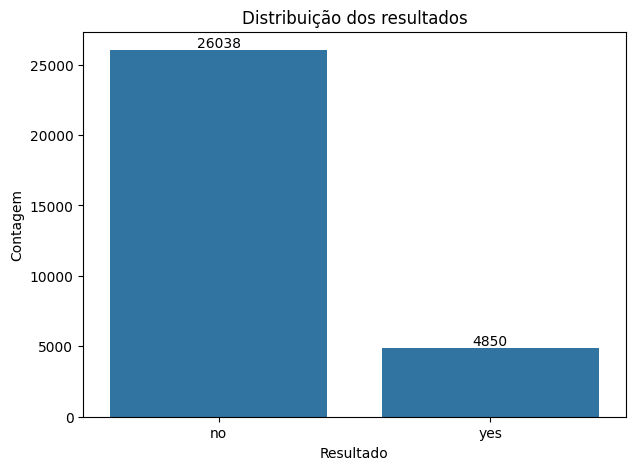

In [125]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
df_deduplicated['result_campaign'] = df_deduplicated['result_campaign'].fillna('NaN')
axes = sns.countplot(x='result_campaign', data=df_deduplicated)
plt.title('Distribuição dos resultados')
plt.xlabel('Resultado')
plt.ylabel('Contagem')
plt.bar_label(axes.containers[0])
plt.show()

Conseguimos uma redução de cerca de 30% da classe majoritária e de 3% na classe minoritária. Embora tenha sido uma boa redução de registros duplicados, a quantidade de registros por categoria ainda é significativamente diferente. Isso pode indicar uma característica do domínio, onde tende-se a adesão à campanha tende a ser mais negativa do que positiva, principalmente considerando que foram contatos por ligação telefônica.

Na etapa de treinamento, algumas técnicas poderão ser empregadas para compensar esse desbalanceamento, como a aplicação de pesos diferentes para cada classe e o uso de cross-validation.

## Transformação e preparação para o treinamento:

In [126]:
df_transformed = df_deduplicated.copy()

In [127]:
df_transformed.columns

Index(['client_age', 'client_job', 'client_marital_status',
       'client_education_level', 'client_financial_default',
       'client_average_annual_balance', 'client_housing_loan',
       'client_personal_loan', 'contact_type', 'contact_day_of_month',
       'contact_month', 'contact_duration', 'number_contacts_campaign',
       'days_last_contact', 'number_contacts_previous_campaign',
       'result_previous_campaign', 'result_campaign', 'client_age_group',
       'contact_week', 'client_average_annual_balance_group',
       'contact_duration_group', 'number_contacts_campaign_group',
       'days_last_contact_group', 'number_contacts_previous_campaign_group'],
      dtype='object')

### Variáveis binárias

Converter variáveis categóricas 'yes'/'no' em binárias 1/0;

In [128]:
df_transformed['client_financial_default_binary'] = df_transformed['client_financial_default'].map({'yes': 1, 'no': 0})
df_transformed['client_housing_loan_binary'] = df_transformed['client_housing_loan'].map({'yes': 1, 'no': 0})
df_transformed['result_campaign_binary'] = df_transformed['result_campaign'].map({'yes': 1, 'no': 0})

### Variáveis categóricas ordinais

Analisando como está a ordem das variáveis:

In [129]:
#Ordinais
ordinais = ['contact_month',
'client_education_level',
'client_age_group',
'contact_week',
'client_average_annual_balance_group',
'contact_duration_group',
'number_contacts_campaign_group',
'days_last_contact_group',
'number_contacts_previous_campaign_group']
for col in ordinais:
    print(f"{col}:", df_transformed[col].unique())
    print("---")


contact_month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
---
client_education_level: ['tertiary' 'secondary' 'unknown' 'primary']
---
client_age_group: ['Meia-idade', 'Adulto', 'Idoso', 'Jovem']
Categories (4, object): ['Jovem' < 'Adulto' < 'Meia-idade' < 'Idoso']
---
contact_week: ['week 1', 'week 2', 'week 3', 'week 4', 'week 5']
Categories (5, object): ['week 1' < 'week 2' < 'week 3' < 'week 4' < 'week 5']
---
client_average_annual_balance_group: [(1536.25, 13014.0], (-0.001, 146.0], (533.0, 1536.25], (146.0, 533.0], 'negative']
Categories (5, object): [(-0.001, 146.0] < (146.0, 533.0] < (533.0, 1536.25] < (1536.25, 13014.0] <
                         'negative']
---
contact_duration_group: [(200.0, 338.0], (124.0, 200.0], (59.999, 124.0], (338.0, 1419.0]]
Categories (4, interval[float64, right]): [(59.999, 124.0] < (124.0, 200.0] < (200.0, 338.0] <
                                           (338.0, 1419.0]]
---
number_contacts_campaign_group: ['(0, 1

Para cada variável, iremos estabelecer a ordem das categorias e aplicar o Ordinal Encoder. Se não estabelecermos a ordem, as categorias seriam aplicadas por ordem alfabética.

Tratando a variável contact_month_order:

In [130]:
contact_month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
encoder = OrdinalEncoder(categories=[contact_month_order])
df_transformed['contact_month_order'] = encoder.fit_transform(
    df_transformed[['contact_month']]
)

Tratando a variável client_education_level_order:

In [131]:
client_education_level_order = ['primary', 'secondary', 'tertiary', 'unknown']
encoder = OrdinalEncoder(categories=[client_education_level_order])
df_transformed['client_education_level_order'] = encoder.fit_transform(
    df_transformed[['client_education_level']]
)

Antes de tratar as variáveis criadas pelo qcut, precisamos converter as faixas de valores de Interval para string.

In [132]:
df_transformed['client_age_group'] = df_transformed['client_age_group'].astype(str)
df_transformed['contact_week'] = df_transformed['contact_week'].astype(str)
df_transformed['client_average_annual_balance_group'] = df_transformed['client_average_annual_balance_group'].astype(str)
df_transformed['contact_duration_group'] = df_transformed['contact_duration_group'].astype(str)
df_transformed['number_contacts_campaign_group'] = df_transformed['number_contacts_campaign_group'].astype(str)
df_transformed['days_last_contact_group'] = df_transformed['days_last_contact_group'].astype(str)
df_transformed['number_contacts_previous_campaign_group'] = df_transformed['number_contacts_previous_campaign_group'].astype(str)

Tratando a variável client_age_group:

In [133]:
client_age_group_order = ['Jovem', 'Adulto', 'Meia-idade', 'Idoso']
encoder = OrdinalEncoder(categories=[client_age_group_order])
df_transformed['client_age_group_order'] = encoder.fit_transform(
    df_transformed[['client_age_group']]
)

Tratando a variável contact_week:

In [134]:
contact_week_order = ['week 1', 'week 2', 'week 3', 'week 4', 'week 5']
encoder = OrdinalEncoder(categories=[contact_week_order])
df_transformed['contact_week_order'] = encoder.fit_transform(
    df_transformed[['contact_week']]
)

Tratando a variável client_average_annual_balance_group:

In [135]:
client_average_annual_balance_group_order = ['negative', '(-0.001, 146.0]', '(146.0, 533.0]', '(533.0, 1536.25]', '(1536.25, 13014.0]']
encoder = OrdinalEncoder(categories=[client_average_annual_balance_group_order])
df_transformed['client_average_annual_balance_group_order'] = encoder.fit_transform(
    df_transformed[['client_average_annual_balance_group']]
)

Tratando a variável contact_duration_group:

In [136]:
contact_duration_group_order = ['(59.999, 124.0]', '(124.0, 200.0]', '(200.0, 338.0]', '(338.0, 1419.0]']
encoder = OrdinalEncoder(categories=[contact_duration_group_order])
df_transformed['contact_duration_group_order'] = encoder.fit_transform(
    df_transformed[['contact_duration_group']]
)

Tratando a variável number_contacts_campaign_group:

In [137]:
number_contacts_campaign_group_order = ['(0, 1]', '(1.999, 3.0]', '(3.0, 4.0]', '(4.0, 16.0]']
encoder = OrdinalEncoder(categories=[number_contacts_campaign_group_order])
df_transformed['number_contacts_campaign_group_order'] = encoder.fit_transform(
    df_transformed[['number_contacts_campaign_group']]
)

Tratando a variável days_last_contact_group:

In [138]:
days_last_contact_group_order = ['never_before', '(0.999, 126.0]', '(126.0, 190.0]', '(190.0, 321.5]', '(321.5, 616.0]',]
encoder = OrdinalEncoder(categories=[days_last_contact_group_order])
df_transformed['days_last_contact_group_order'] = encoder.fit_transform(
    df_transformed[['days_last_contact_group']]
)

Tratando a variável number_contacts_previous_campaign_group:

In [139]:
number_contacts_previous_campaign_group_order = ['not_contacted', '(0.999, 2.0]', '(2.0, 4.0]', '(4.0, 20.0]']
encoder = OrdinalEncoder(categories=[number_contacts_previous_campaign_group_order])
df_transformed['number_contacts_previous_campaign_group_order'] = encoder.fit_transform(
    df_transformed[['number_contacts_previous_campaign_group']]
)

Verificando as variáveis após o encoder:

In [140]:
ordinais = [
  'contact_month_order',
  'client_education_level_order',
  'client_age_group_order',
  'contact_week_order',
  'client_average_annual_balance_group_order',
  'contact_duration_group_order',
  'number_contacts_campaign_group_order',
  'days_last_contact_group_order',
  'number_contacts_previous_campaign_group_order'
]
for col in ordinais:
    print(f"{col}:", df_transformed[col].unique())
    print("---")

contact_month_order: [ 4.  5.  6.  7.  9. 10. 11.  0.  1.  2.  3.  8.]
---
client_education_level_order: [2. 1. 3. 0.]
---
client_age_group_order: [2. 1. 3. 0.]
---
contact_week_order: [0. 1. 2. 3. 4.]
---
client_average_annual_balance_group_order: [4. 1. 3. 2. 0.]
---
contact_duration_group_order: [2. 1. 0. 3.]
---
number_contacts_campaign_group_order: [0. 1. 3. 2.]
---
days_last_contact_group_order: [0. 2. 1. 3. 4.]
---
number_contacts_previous_campaign_group_order: [0. 1. 2. 3.]
---


As categorias foram convertidas em valores numéricos.

### Variáveis categóricas nominais

Para as variáveis nominais, a ordem não importa, então iremos aplicar o OneHotEncoding, que gera novas colunas binárias indicando qual a categoria representada.

In [141]:
#Independentes
nominais = [
  'client_job',
  'client_marital_status',
  'contact_type',
  'result_previous_campaign',
  'result_campaign',
]

#Criando encoder
encoder = OneHotEncoder(sparse_output=False)
#Codificando colunas
encoded = encoder.fit_transform(df_transformed[nominais])
#Criando novo dataframe com as novas colunas
encoded_df = pd.DataFrame(encoded,
                          columns=encoder.get_feature_names_out(nominais),
                          index=df_transformed.index)
#Concatenando novas colunas com o dataframe anterior:
df_transformed = pd.concat([df_transformed, encoded_df], axis=1)

Vejamos o resultado final do dataset:

In [142]:
df_transformed

,client_age,client_job,client_marital_status,client_education_level,client_financial_default,client_average_annual_balance,client_housing_loan,client_personal_loan,contact_type,contact_day_of_month,...,client_marital_status_single,contact_type_cellular,contact_type_telephone,contact_type_unknown,result_previous_campaign_N/A,result_previous_campaign_failure,result_previous_campaign_other,result_previous_campaign_success,result_campaign_no,result_campaign_yes
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Respondendo nossas hipóteses


## Hipótese 1

> Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?

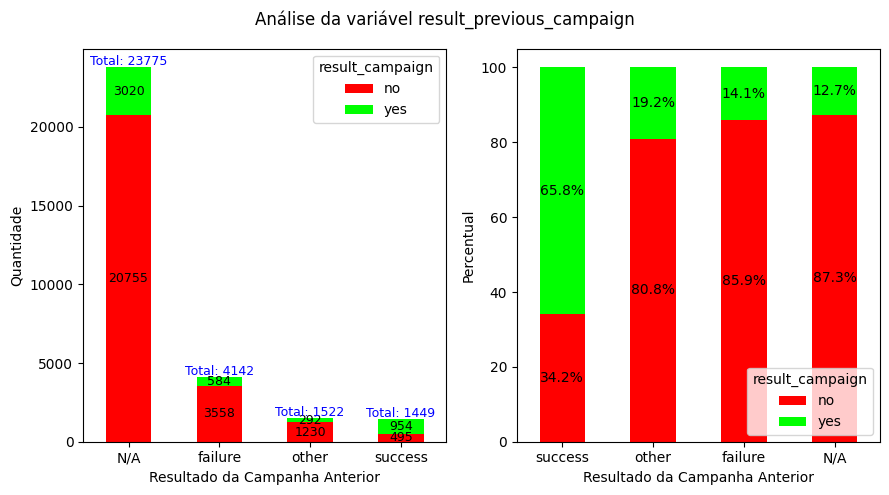

In [143]:
figsize = (9, 5)
variable = 'result_previous_campaign'
label = 'Resultado da Campanha Anterior'
target = 'result_campaign'
df_group = plot_bar_by_hue_result(figsize, df_transformed, variable, label, target)

Embora haja uma grande quantidade de clientes que não foram contactados em campanhas anteriores (23775) e que os casos de clientes que foram contactados em campanhas anteriores sejam a menor quantidade de ocorrências (1449), ao observar os percentuais de aceitação da campanha atual, a maioria dos clientes que aceitaram a campanha anterior, também aceitaram a campanha atual.

Então podemos responder que sim, os clientes com sucesso na campanha anterior, foram os mais dispostos a aceitar novamente a campanha. Isso pode indicar que o produto foi muito bem avaliado pelos clientes.

## Hipótese 2

> Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?

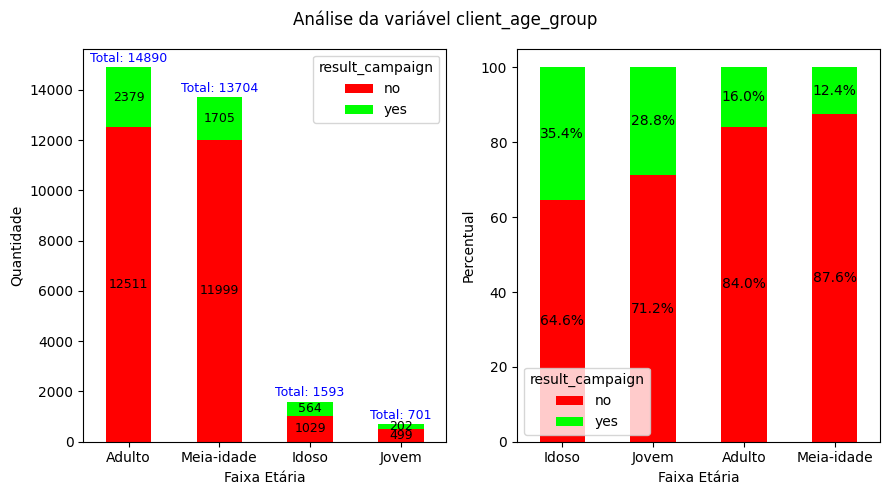

In [144]:
figsize = (9, 5)
variable = 'client_age_group'
label = 'Faixa Etária'
target = 'result_campaign'
df_group = plot_bar_by_hue_result(figsize, df_transformed, variable, label, target)

Embora o grupo de jovens foi o menos contactado durante a campanha, a análise percentual revela que foi o grupo com segunda maior taxa de aceitação, estando atrás apenas dos idosos, mas na frente dos considerados adultos (25 a 60 anos).

Então, embora seja necessário uma maior quantidade de contatos com o público jovem, podemos dizer que sim, este público tem uma taxa de aceitação maior do que o de adultos.

## Hipótese 3

> Ligar mais vezes para um cliente diminui a chance dele contratar?

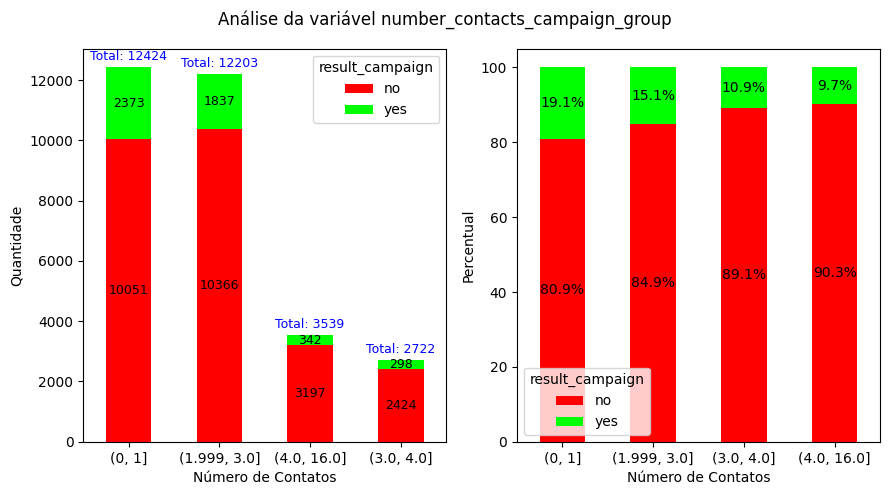

In [145]:
figsize = (9, 5)
variable = 'number_contacts_campaign_group'
label = 'Número de Contatos'
target = 'result_campaign'
df_group = plot_bar_by_hue_result(figsize, df_transformed, variable, label, target)

A grande maioria dos clientes só foram contactados de 1 a 3 vezes. No entanto, observando o gráfico da direita, o percentual com menor taxa de aceitação foi os clientes que receberam de 4 contatos para cima.

Isso revela, que contactar mais de 4 vezes um cliente, dificilmente aumenta as chances dele querer contratar o produto, e que os clientes que estão interessados, geralmente tomam essa decisão entre 1 a 3 contatos.

Então, respondendo a nossa hipótese, podemos dizer sim, diminui, mas melhor seria dizer que não aumenta as chances, pois a maioria dos clientes tomam a decisão nos primeiros contatos.

## Hipótese 4

> Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?

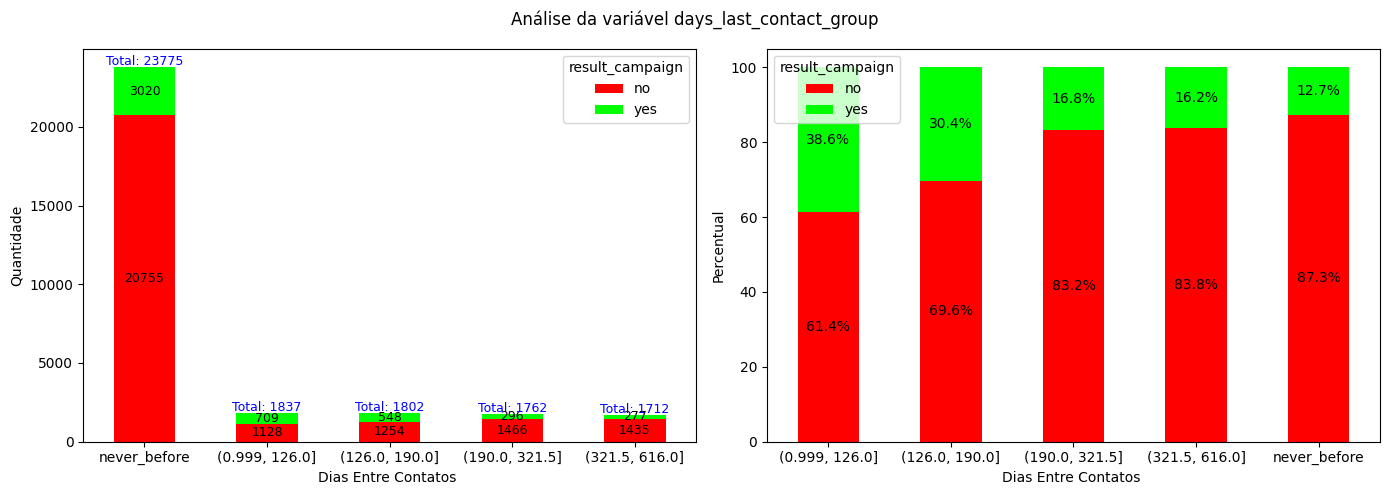

In [146]:
figsize = (14, 5)
variable = 'days_last_contact_group'
label = 'Dias Entre Contatos '
target = 'result_campaign'
df_group = plot_bar_by_hue_result(figsize, df_transformed, variable, label, target)

A grande maiorria dos clientes foi contactado pela primeira vez nessa campanha (23775). Dentre os que já tinham sido contactados em campanhas anteriores, a taxa de aceitação está bem maior dentre o período de 1 a 126 dias, seguido pelo período de 127 a 190 dias.

Então podemos dizer, que até 190 dias do contato realizado em campanhas anteriores, os clientes estão mais sucetíveis a repensarem a proposta e aceitar o produto. Após esse período, a taxa de aceitação cai significativamente.

Respondendo a hipótese, depende, até 200 dias é considerado tempo saudável e que geralmente trás bom resultados. Após esse período, diminui significativamente os casos positivos.

# Conclusão

A análise e pré-processamento do dataset Bank Marketing demonstram a importância de entender a estrutura dos dados antes da modelagem. Embora o dataset esteja limpo, é extremamente desbalanceado, o que dificulta significativamente a análise do problema. Apesar do desbalanceamento, a análise exploratória revelou características importantes do problema, como maior taxa de aceitação entre clientes que já haviam assinado o produto, ou até mesmo uma quantidade de contatos mais adequada para maximizar a aceitação da campanha.

Embora, o desbalanceamento do dataset dificulte a análise mais clara dos resutlados, podemos afirmar que as quatro hipóteses levantadas foram validadas:

1. **Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?**
*Sim, os clientes com sucesso na campanha anterior, foram os mais dispostos a aceitar novamente a campanha.*
2. **Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?**
*Sim, o público jovem teve maior taxa de aceitação do que o de adultos.*
3. **Ligar mais vezes para um cliente diminui a chance dele contratar?**
*Podemos dizer sim, mas melhor seria dizer que não aumenta as chances.*
4. **Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?**
*Depende, até 200 dias é considerado tempo saudável e que geralmente trás bom resultados. Após esse período, diminui significativamente os casos positivos.*